<a href="https://colab.research.google.com/github/Ascenderr999/devjoint-intern-job/blob/main/Devjoint_week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>









































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































# Bina.az satış elanları üzərində mənzil qiymətinin proqnozlaşdırılması

Bu layihədə Bina.az-dan toplanmış satış elanları datası üzərində uçdan-uca bir maşın öyrənməsi pipeline-ı qurmuşam: xam datanın yüklənməsindən başlayıb, təmizləmə və kəşfiyyat analizindən keçərək, bir neçə alqoritmin müqayisəsinə, ən yaxşısının tənzimlənməsinə, yekun qiymətləndirməyə, modelin saxlanmasına və biznes tərəfdaşı üçün hesabata qədər.

**Data mənbəyi:** https://www.kaggle.com/datasets/sehriyarmemmedli/binaaz-sale-project

Notebook-un gedişatı:

1. Problemin çərçivələnməsi
2. Datanın yüklənməsi, təmizlənməsi və kəşfiyyat analizi (EDA)
3. Beş modelin eyni metodologiya ilə müqayisəsi
4. Ən yaxşı modelin hyperparameter tuning-i
5. Yekun modelin ayrılmış test setində qiymətləndirilməsi
6. Modelin saxlanması
7. Biznes tərəfdaşı üçün hesabat

Bütün işi bir prinsip üzərində qurmuşam: **test setinə yalnız işin ən sonunda, bir dəfə toxunulur.** Data yüklənən kimi test hissəsini ayırıram və ondan sonra nə EDA-da, nə təmizləmədə, nə model seçimində, nə də tuning-də ona baxmıram. Buna görə də 5-ci bölmədəki rəqəmlər modelin real şəraitdə gözlənilən performansıdır, öz məşq datasındakı balı deyil.

İkinci prinsip: heç bir metriki tək rəqəm kimi vermirəm. Bütün cross-validation nəticələrini fold-lar arası orta ± standart kənarlaşma və 95% etibar intervalı ilə göstərirəm, çünki tək bir RMSE rəqəmi modelin nə qədər stabil olduğunu gizlədir.

## Mühitin hazırlanması

Burada işlədəcəyim kitabxanaları yükləyirəm və təsadüfi toxumu (`RANDOM_STATE = 42`) sabitləyirəm. Bunu ona görə edirəm ki, notebook-u kim işə salırsa salsın, eyni bölgü, eyni fold-lar və eyni nəticələr alsın — əks halda modelləri müqayisə etməyin mənası olmazdı, fərq təsadüfdən gələ bilərdi.

In [2]:
import subprocess, sys, importlib, warnings, os, re, json, time
warnings.filterwarnings("ignore")

for pkg in ["kagglehub", "joblib", "seaborn"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("RANDOM_STATE:", RANDOM_STATE)

pandas      : 2.2.2
numpy       : 2.0.2
scikit-learn: 1.6.1
RANDOM_STATE: 42


---
# Checkpoint 1 — Problemin çərçivələnməsi

## Biznes problemi

Bina.az kimi elan platformasında qiyməti mənzilin sahibi özü təyin edir və bu qərar çox vaxt qonşunun elanına və ya hissiyyata əsaslanır. Nəticədə iki problem yaranır:

- Bazar səviyyəsindən yuxarı qiymət qoyulan elan aylarla satılmır və elan lentini doldurur.
- Bazardan aşağı qoyulan qiymət isə satıcı üçün birbaşa maliyyə itkisidir.

Alıcı tərəfdə də vəziyyət eynidir: hansı elanın həqiqətən sərfəli, hansının şişirdilmiş olduğunu obyektiv müəyyən etmək mümkün deyil, bu isə platformaya olan etibarı azaldır.

Mənim həll təklifim: mənzilin obyektiv xüsusiyyətlərinə — sahə, otaq sayı, mərtəbə, rayon, təmir vəziyyəti, tikili tipi və s. — əsaslanaraq bazar qiymətini avtomatik proqnozlaşdıran model qurmaq.

Modelin harada işləyəcəyini də əvvəlcədən düşünmüşəm:

1. Elan yerləşdirilərkən satıcıya tövsiyə olunan qiymət aralığını göstərmək.
2. Proqnozdan xeyli aşağı qiymətli elanları alıcılara "əlverişli təklif" kimi təqdim etmək.
3. Proqnozdan kəskin fərqlənən elanları moderasiyaya yönləndirmək.
4. Rayonlar üzrə qiymət dinamikasını izləmək üçün daxili analitika.

## Target dəyişən

Hədəf dəyişən **qiymətdir (AZN)** və o, kəsilməz ədədi dəyişəndir — deməli qarşımdakı məsələ **reqressiyadır**, təsnifat deyil.

Daşınmaz əmlak qiymətləri demək olar ki, həmişə sağa əyilmiş paylanmaya malikdir: elanların böyük hissəsi orta seqmentdə cəmləşir, az sayda çox bahalı obyekt isə uzun sağ quyruq yaradır. Buna görə modelləri **log(1+qiymət)** üzərində öyrədirəm və proqnozları metrik hesablamadan əvvəl `expm1` ilə geri AZN-ə çevirirəm. Belə etməsəm, bir neçə bahalı villa bütün modeli öz üzərinə çəkər və orta seqmentdəki proqnozların keyfiyyəti düşərdi.

## Uğur metrikaları

Əsas metrik kimi **RMSE**-ni seçmişəm, çünki o, böyük səhvləri kvadratik cəzalandırır — qiymət proqnozunda isə ən bahalı səhv məhz böyük səhvdir. Model seçimini bu metrikə görə edirəm.

Köməkçi metriklər:

- **MAE** — "orta halda neçə manat yanılırıq", biznes tərəfdaşı üçün ən başadüşülən rəqəm.
- **MAPE (%)** — səhvi faizlə ifadə edir, ucuz və baha mənzilləri müqayisə etməyə imkan verir.
- **R²** — model qiymətdəki dəyişkənliyin neçə faizini izah edir.

## Uğur meyarı

Meyarı işə başlamazdan əvvəl təyin edirəm ki, sonradan nəticəyə uyğunlaşdırmayım. Baseline olaraq ən sadə "modeli" götürürəm: hər mənzilə train setinin median qiymətini vermək. Model bu baseline-dan **RMSE üzrə ən azı 40% yaxşı** olmalı və test setində **MAPE ≤ 25%** göstərməlidir ki, məhsulda tövsiyə olunan qiymət kimi göstərilə bilsin.

## Qiymətləndirmə protokolu

- Data 80% train / 20% test kimi bölünür, `random_state=42`, qiymət kvantilləri üzrə stratifikasiya ilə.
- Model seçimi train üzərində `KFold(n_splits=5, shuffle=True, random_state=42)` ilə aparılır və bu obyekt bir dəfə yaradılıb bütün modellərə ötürülür, yəni hamısı eyni fold-lar üzərində qiymətləndirilir.
- Test seti kənara qoyulur və yalnız 5-ci bölmədə açılır.

---
# Checkpoint 2 — Datanın yüklənməsi, təmizlənməsi və EDA

## Datanın yüklənməsi

Datanı birbaşa Kaggle-dan `kagglehub` ilə çəkirəm. Colab ilk dəfə Kaggle hesabı üçün token soruşa bilər.

In [3]:
import kagglehub

path = kagglehub.dataset_download("sehriyarmemmedli/binaaz-sale-project")

data_files = []
for root, _, fnames in os.walk(path):
    for f in fnames:
        if f.lower().endswith((".csv", ".xlsx", ".xls")):
            data_files.append(os.path.join(root, f))

data_files.sort(key=lambda f: -os.path.getsize(f))
data_path = data_files[0]

if data_path.lower().endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(data_path)
else:
    df_raw = pd.read_csv(data_path)

print("Fayl :", os.path.basename(data_path))
print("Ölçü :", df_raw.shape[0], "sətir ×", df_raw.shape[1], "sütun")
df_raw.head()

Using Colab cache for faster access to the 'binaaz-sale-project' dataset.
Fayl : house_sale.csv
Ölçü : 100775 sətir × 51 sütun


,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,"499,999.00",AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,"499,999.00",AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.36,49.82,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.00,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,"77,000.00",AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,"77,000.00",AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.42,49.81,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.00,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,"92,000.00",AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,"92,000.00",AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.39,49.80,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.00,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,"95,000.00",AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,"95,000.00",AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.39,49.98,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,"220,000.00",AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga du

## Datanın ilkin mənzərəsi

Təmizləməyə başlamazdan əvvəl datanın "pasportunu" çıxarıram: hansı sütunlar var, tipləri nədir, hər sütunda nə qədər boş dəyər və nə qədər unikal dəyər var, nümunə dəyər necə görünür. Bu addımı atlasam, sonrakı bütün təmizləmə qərarlarım kor-koranə olardı.

In [4]:
info = pd.DataFrame({
    "tip": df_raw.dtypes.astype(str),
    "boş_say": df_raw.isna().sum(),
    "boş_%": (df_raw.isna().mean() * 100).round(2),
    "unikal_say": df_raw.nunique(),
    "nümunə": [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None for c in df_raw.columns],
})
display(info)

print("Tam təkrarlanan sətirlərin sayı:", df_raw.duplicated().sum())
print("Ümumi boş xana faizi: %.2f%%" % (df_raw.isna().mean().mean() * 100))

,tip,boş_say,boş_%,unikal_say,nümunə
id_x,object,0,0.00,100775,5df36281-6dc6-4d5d-89a7-5fcfa86f7608
rel_url,object,0,0.00,411,/alqi-satqi?page=174
estate_rel_url_x,object,0,0.00,64454,/items/4521724
datetime_scrape_x,object,0,0.00,36,2024-10-05 22:07:37.60613+00
price,float64,0,0.00,2772,"499,999.00"
currency_x,object,0,0.00,1,AZN
location,object,0,0.00,142,Səbail r.
attributes,object,0,0.00,21347,"4 otaqlı, 145 m², 7/9 mərtəbə"
city_when,object,0,0.00,1504,"Bakı, dünən 23:52"
city,object,0,0.00,8,bakı


Tam təkrarlanan sətirlərin sayı: 0
Ümumi boş xana faizi: 15.35%


## Sütunların tipə çevrilməsi

Elan datasında rəqəmlər mətn şəklində saxlanılır: qiymət `"150 000"`, sahə `"80 m²"`, mərtəbə isə `"5/9"` (yəni 9 mərtəbəli binanın 5-ci mərtəbəsi) kimi. Bu formada onlar model üçün yararsızdır.

Bu addımda üç iş görürəm. Əvvəlcə sütun adlarındakı artıq boşluqları təmizləyirəm və qiymət, sahə, otaq, mərtəbə sütunlarını açar sözlərlə tapıram — dataset yenilənib sütun adları bir az dəyişsə də kod işləməyə davam etsin deyə. Sonra `"5/9"` formatındakı mərtəbə sahəsini iki ayrı dəyişənə bölürəm: mərtəbənin özü və binanın ümumi mərtəbə sayı, çünki bunlar qiymətə fərqli təsir edən iki müxtəlif məlumatdır. Nəhayət, mətn kimi saxlanan bütün rəqəmli sahələri ədədə çevirirəm. Burada diqqətli olmuşam: çevirmə yalnız həqiqətən "ədəd + ölçü vahidi" formasında olan sütunlara tətbiq olunur, əks halda `"küç. 12"` kimi ünvan sahəsi də səhvən ədədə çevrilərdi.

In [5]:
df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

KEYS = {
    "price":    ["qiym", "price", "məbləğ", "mebleg", "cost"],
    "area":     ["sah", "area", "kvadrat", "metr", "m2", "m²"],
    "rooms":    ["otaq", "room"],
    "floor":    ["mərtəbə", "mertebe", "floor"],
    "currency": ["valyuta", "currency", "pul"],
}

def is_text_col(s):
    return not pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s)

def text_columns(frame):
    return [c for c in frame.columns if is_text_col(frame[c])]

def find_col(frame, keys):
    for c in frame.columns:
        if any(k in str(c).lower() for k in keys):
            return c
    return None

COL = {k: find_col(df, v) for k, v in KEYS.items()}
print("Tanınan sütunlar:", {k: v for k, v in COL.items() if v})

def to_number(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).replace("\xa0", " ").strip()
    if "/" in s:
        s = s.split("/")[0]
    s = re.sub(r"[^0-9,.\-]", "", s)
    if s in ("", "-", ".", ","):
        return np.nan
    if "," in s and "." in s:
        s = s.replace(",", "")
    elif "," in s:
        s = s.replace(",", ".") if len(s.split(",")[-1]) <= 2 else s.replace(",", "")
    try:
        return float(s)
    except ValueError:
        return np.nan

fc = COL["floor"]
if fc is not None and df[fc].astype(str).str.contains("/").mean() > 0.3:
    parts = df[fc].astype(str).str.split("/", n=1, expand=True)
    df["mertebe"] = parts[0].apply(to_number)
    df["bina_mertebe_sayi"] = parts[1].apply(to_number)
    df = df.drop(columns=[fc])
    COL["floor"] = "mertebe"
    print("Mərtəbə sahəsi iki dəyişənə bölündü: mertebe + bina_mertebe_sayi")

for k in ["price", "area", "rooms", "floor"]:
    c = COL.get(k)
    if c is not None and is_text_col(df[c]):
        df[c] = df[c].apply(to_number)

UNIT_RE = re.compile(r"(m²|m2|azn|usd|eur|manat|\$|₼)", re.I)

def looks_numeric(v):
    if pd.isna(v):
        return False
    t = str(v)
    if not re.search(r"\d", t):
        return False
    return re.fullmatch(r"[\s\d.,/\-]*", UNIT_RE.sub("", t)) is not None

for c in text_columns(df):
    vals = df[c].dropna()
    if len(vals) and vals.map(looks_numeric).mean() >= 0.9 and df[c].nunique() > 10:
        df[c] = df[c].apply(to_number)

PRICE = COL["price"]
print("Target:", PRICE)
df[[c for c in [PRICE, COL.get("area"), COL.get("rooms"), COL.get("floor")] if c]].describe()

Tanınan sütunlar: {'price': 'price', 'area': 'Sahə', 'rooms': 'Otaq sayı', 'floor': 'Mərtəbə', 'currency': 'currency_x'}
Mərtəbə sahəsi iki dəyişənə bölündü: mertebe + bina_mertebe_sayi
Target: price


,price,Sahə,Otaq sayı,mertebe
count,"100,775.00","100,775.00","91,363.00","75,996.00"
mean,"342,355.74",143.94,3.13,7.85
std,"2,042,626.62","1,004.40",1.37,4.89
min,11.00,0.20,1.00,1.00
25%,"145,000.00",65.35,2.00,4.00
50%,"218,000.00",100.00,3.00,7.00
75%,"338,000.00",145.00,4.00,11.00
max,"600,000,000.00","200,000.00",20.00,27.00


## Sətir səviyyəsində təmizləmə

Burada yalnız məntiqi qaydalara əsaslanan təmizləmə aparıram və bilərəkdən datadan öyrənilən heç bir statistikadan istifadə etmirəm. Səbəbi budur: əgər təmizləmə üçün bütün datanın kvantillərini və ya ortalarını hesablasaydım, test setinin məlumatı dolayı yolla prosesə sızardı.

Tətbiq etdiyim qaydalar:

- Tam təkrarlanan sətirləri silirəm, çünki eyni elan platformada bir neçə dəfə yerləşdirilə bilər.
- Qiyməti boş və ya sıfırdan kiçik olan sətirləri silirəm — targeti olmayan sətir modelə heç nə vermir.
- Qiyməti qeyri-real dərəcədə aşağı olan elanları silirəm; belələri adətən test məqsədilə yerləşdirilmiş və ya səhvən doldurulmuş elanlardır.
- Sahəsi sıfır və ya 5 m²-dən kiçik olan sətirləri silirəm.
- Datada valyuta sütunu varsa, yalnız ən çox rast gəlinən valyutanı saxlayıram, çünki manat və dolları qarışdırsam target tamamilə mənasız olar.
- Faydasız sütunları atıram: identifikator, elan linki və bütün sətirlərdə eyni dəyəri olan sütunlar.

Statistikaya əsaslanan outlier təmizləməsini burada yox, bölgüdən sonra və yalnız train üzərində aparacağam.

In [6]:
n0 = len(df)
log_steps = []

df = df.drop_duplicates()
log_steps.append(("Təkrar sətirlər silindi", n0 - len(df)))

n = len(df)
df = df[df[PRICE].notna() & (df[PRICE] > 0)]
log_steps.append(("Qiyməti boş və ya ≤0 olanlar silindi", n - len(df)))

if df[PRICE].median() > 10000:
    n = len(df)
    df = df[df[PRICE] >= 1000]
    log_steps.append(("Qeyri-real ucuz elanlar silindi", n - len(df)))

AREA = COL.get("area")
if AREA:
    n = len(df)
    df = df[df[AREA].isna() | (df[AREA] > 0)]
    log_steps.append(("Sahəsi ≤0 olanlar silindi", n - len(df)))
    if df[AREA].median() > 20:
        n = len(df)
        df = df[df[AREA].isna() | (df[AREA] >= 5)]
        log_steps.append(("Sahəsi <5 m² olanlar silindi", n - len(df)))

CUR = COL.get("currency")
if CUR and CUR in df.columns and is_text_col(df[CUR]):
    top_cur = df[CUR].mode()[0]
    n = len(df)
    df = df[df[CUR] == top_cur]
    log_steps.append((f"Yalnız '{top_cur}' valyutası saxlanıldı", n - len(df)))
    df = df.drop(columns=[CUR])

drop_cols = []
for c in df.columns:
    if c == PRICE:
        continue
    lc = str(c).lower()
    if any(k in lc for k in ["id", "link", "url", "unnamed", "index"]) and df[c].nunique() > 0.5 * len(df):
        drop_cols.append(c)
    elif is_text_col(df[c]) and df[c].astype(str).str.contains("http", case=False, na=False).mean() > 0.5:
        drop_cols.append(c)
    elif df[c].nunique() <= 1:
        drop_cols.append(c)
if drop_cols:
    df = df.drop(columns=drop_cols)

print("TƏMİZLƏMƏ JURNALI")
print("-" * 55)
for name, cnt in log_steps:
    print(f"{name:<45} {cnt:>7,}")
print(f"{'Atılan sütunlar':<45} {len(drop_cols):>7}  {drop_cols}")
print("-" * 55)
print(f"{'Başlanğıc sətir sayı':<45} {n0:>7,}")
print(f"{'Qalan sətir sayı':<45} {len(df):>7,}  ({len(df)/n0*100:.1f}%)")
df.head()

TƏMİZLƏMƏ JURNALI
-------------------------------------------------------
Təkrar sətirlər silindi                             0
Qiyməti boş və ya ≤0 olanlar silindi                0
Qeyri-real ucuz elanlar silindi                    10
Sahəsi ≤0 olanlar silindi                           0
Sahəsi <5 m² olanlar silindi                      895
Yalnız 'AZN' valyutası saxlanıldı                   0
Atılan sütunlar                                    19  ['id_x', 'estate_rel_url_x', 'day_x', 'repair', 'vip', 'featured', 'bill_of_sale', 'mortgage', 'img_url', 'id_y', 'estate_id', 'estate_rel_url_y', 'currency_y', 'shop_title', 'day_y', 'estate_details_id_x', 'İpoteka', 'estate_details_id_y', 'estate_rel_url']
-------------------------------------------------------
Başlanğıc sətir sayı                          100,775
Qalan sətir sayı                               99,870  (99.1%)


,rel_url,datetime_scrape_x,price,location,attributes,city_when,city,hour_x,products_label,datetime_scrape_y,description,unit_price,total_price,owner_name,owner_title,shop_name,address,lat,lng,updated,views,hour_y,Binanın növü,Kateqoriya,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,extra_info,mertebe,bina_mertebe_sayi
0,/alqi-satqi?page=174,2024-10-05 22:07:37.60613+00,"499,999.00",Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,23:52,NaN,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...","3,450.00","499,999.00",Kamran,mülkiyyətçi,NaN,İzzət Nəbiyev küç.,40.36,49.82,yeniləndi: dünən 23:52,1155,23:52,NaN,Köhnə tikili,4.00,145.00,NaN,var,var,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.,7.00,9.00
1,/alqi-satqi?page=250,2024-10-05 22:07:37.60613+00,"77,000.00",Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,23:56,NaN,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,"77,000.00",Dasinmaz Emlak,vasitəçi (agent),NaN,Biləcəri qəs.,40.42,49.81,yeniləndi: 04 oktyabr 2024,218,NaN,NaN,Həyət evi/Bağ evi,4.00,90.00,1.3 sot,var,yoxdur,Binəqədi r.* Biləcəri q.,NaN,NaN
2,/alqi-satqi?page=250,2024-10-05 22:07:37.60613+00,"92,000.00",İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,23:55,NaN,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,"92,000.00",Məhəmməd,vasitəçi (agent),NaN,Mirzə Cabbar Məmmədzadə küç.,40.39,49.80,yeniləndi: 04 oktyabr 2024,190,NaN,NaN,Həyət evi/Bağ evi,3.00,60.00,0.1 sot,var,var,İnşaatçılar m.* Yasamal r.,NaN,NaN
3,/alqi-satqi?page=250,2024-10-05 22:07:37.60613+00,"95,000.00",Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,23:55,NaN,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,"95,000.00",Elçin,mülkiyyətçi,NaN,Qaraçuxur qəs.,40.39,49.98,yeniləndi: 04 oktyabr 2024,1314,NaN,NaN,Obyekt,NaN,130.00,NaN,var,var,Suraxanı r.* Qaraçuxur q.,NaN,NaN
4,/alqi-satqi?page=250,2024-10-05 22:07:37.60613+00,"220,000.00",Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,23:52,Agentlik,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...,"2,200.00","220,000.00",Dürdanə,vasitəçi (agent),Elite Ofis,Qaçaq Nəbi küç.,40.39,49.96,yeniləndi: 04 oktyabr 2024,240,NaN,NaN,Yeni tikili,3.00,100.00,NaN,var,var,Əhmədli m.* Xalqlar Dostluğu m.* Xətai r.* Əhm...,15.00,16.00


## Train / test bölgüsü — EDA-dan əvvəl

Bölgünü bilərəkdən EDA-dan əvvələ qoymuşam və bu, bütün layihənin ən kritik qərarıdır.

Əgər əvvəlcə bütün data üzərində analiz edib sonra bölsəydim, artıq test setindəki qiymət paylanmasını, korrelyasiyaları, hansı rayonun baha olduğunu görmüş olardım. Bu məlumat isə istər-istəməz mənim seçimlərimə təsir edərdi — hansı dəyişəni saxlayacağıma, hansı elanı outlier sayacağıma. Nəticədə test seti artıq "təmiz gələcək" olmazdı və model əslində olduğundan yaxşı görünərdi. Bu, data leakage-in ən çox yayılmış formasıdır.

Ona görə də bölgünü indi, hər hansı qrafikdən əvvəl edirəm. Bundan sonra `X_test` və `y_test` 5-ci bölməyə qədər heç bir yerdə iştirak etmir.

Bölgünü qiymət kvantilləri üzrə stratifikasiya ilə edirəm ki, ucuz və baha seqmentlər hər iki hissədə eyni nisbətdə təmsil olunsun — tam təsadüfi bölgü seqment balansını poza bilər.

In [7]:
y_all = df[PRICE].astype(float)
X_all = df.drop(columns=[PRICE])

try:
    strata = pd.qcut(y_all, q=5, labels=False, duplicates="drop")
except Exception:
    strata = None

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=strata
)

print(f"TRAIN : {X_train.shape[0]:,} sətir  ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"TEST  : {X_test.shape[0]:,} sətir  ({X_test.shape[0]/len(df)*100:.0f}%)  — kənara qoyuldu")

train = X_train.copy()
train[PRICE] = y_train

TRAIN : 79,896 sətir  (80%)
TEST  : 19,974 sətir  (20%)  — kənara qoyuldu


## Kəşfiyyat analizi

Bütün analizi yalnız train seti üzərində aparıram.

### Qiymətin paylanması

Əvvəlcə proqnozlaşdırmaq istədiyim dəyişəni tanıyıram. Gözləntim güclü sağa əyilmə və uzun sağ quyruqdur; bunu təsdiqləsəm, target-i loqarifmik çevirmək qərarım əsaslandırılmış olacaq.

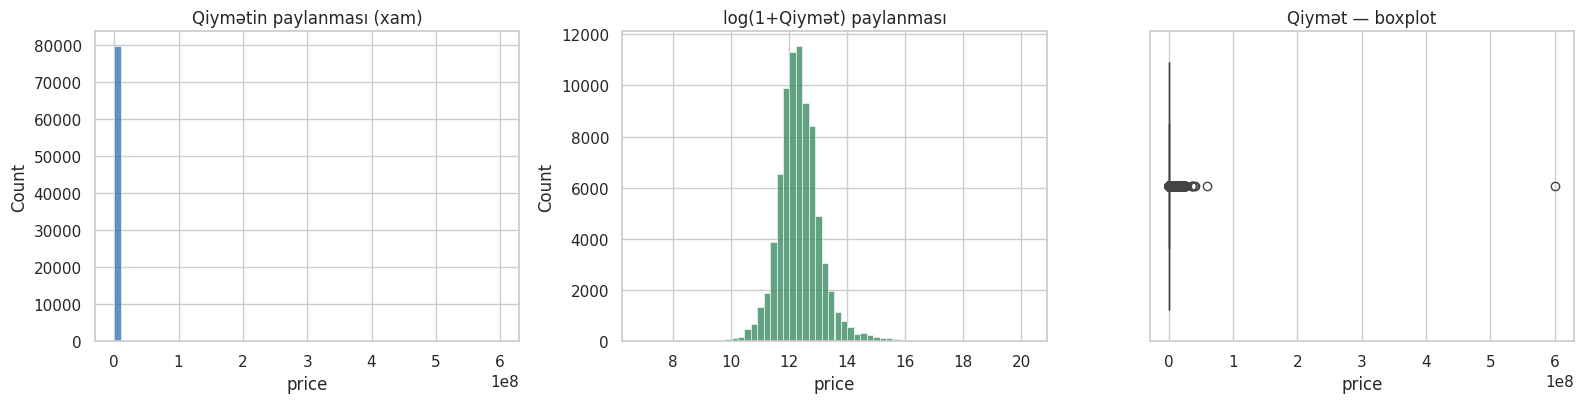

Əyrilik, xam qiymət : 233.06
Əyrilik, log qiymət : 0.45


,Qiymət
count,"79,896.00"
mean,"347,214.04"
std,"2,265,641.99"
min,"1,000.00"
1%,"37,000.00"
5%,"75,000.00"
25%,"145,000.00"
50%,"219,900.00"
75%,"339,000.00"
95%,"780,000.00"


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(train[PRICE], bins=60, ax=ax[0], color="#2b6cb0")
ax[0].set_title("Qiymətin paylanması (xam)")

sns.histplot(np.log1p(train[PRICE]), bins=60, ax=ax[1], color="#2f855a")
ax[1].set_title("log(1+Qiymət) paylanması")

sns.boxplot(x=train[PRICE], ax=ax[2], color="#c05621")
ax[2].set_title("Qiymət — boxplot")
plt.tight_layout(); plt.show()

print(f"Əyrilik, xam qiymət : {train[PRICE].skew():.2f}")
print(f"Əyrilik, log qiymət : {np.log1p(train[PRICE]).skew():.2f}")
display(train[PRICE].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("Qiymət"))

Xam qiymətin əyriliyi yüksək müsbətdir, log-çevrilmədən sonra isə paylanma normal paylanmaya xeyli yaxınlaşır. Bu, modelləri `TransformedTargetRegressor` ilə log-məkanda öyrətmək qərarımı təsdiqləyir.

### Digər dəyişənlərin paylanması və boş dəyərlər

Boş dəyərlərin harada və nə qədər olduğunu bilmək imputasiya strategiyasını müəyyən edir. Amma boşluqları burada doldurmuram — doldurmanı pipeline-ın içində edəcəyəm ki, hər fold-da yalnız həmin fold-un train hissəsindən öyrənilsin.

Ədədi dəyişənlər     : ['unit_price', 'total_price', 'lat', 'lng', 'views', 'Otaq sayı', 'Sahə', 'mertebe', 'bina_mertebe_sayi']
Kateqorik dəyişənlər : ['rel_url', 'datetime_scrape_x', 'location', 'attributes', 'city_when', 'city', 'hour_x', 'products_label', 'datetime_scrape_y', 'description', 'owner_name', 'owner_title', 'shop_name', 'address', 'updated', 'hour_y', 'Binanın növü', 'Kateqoriya', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'extra_info']


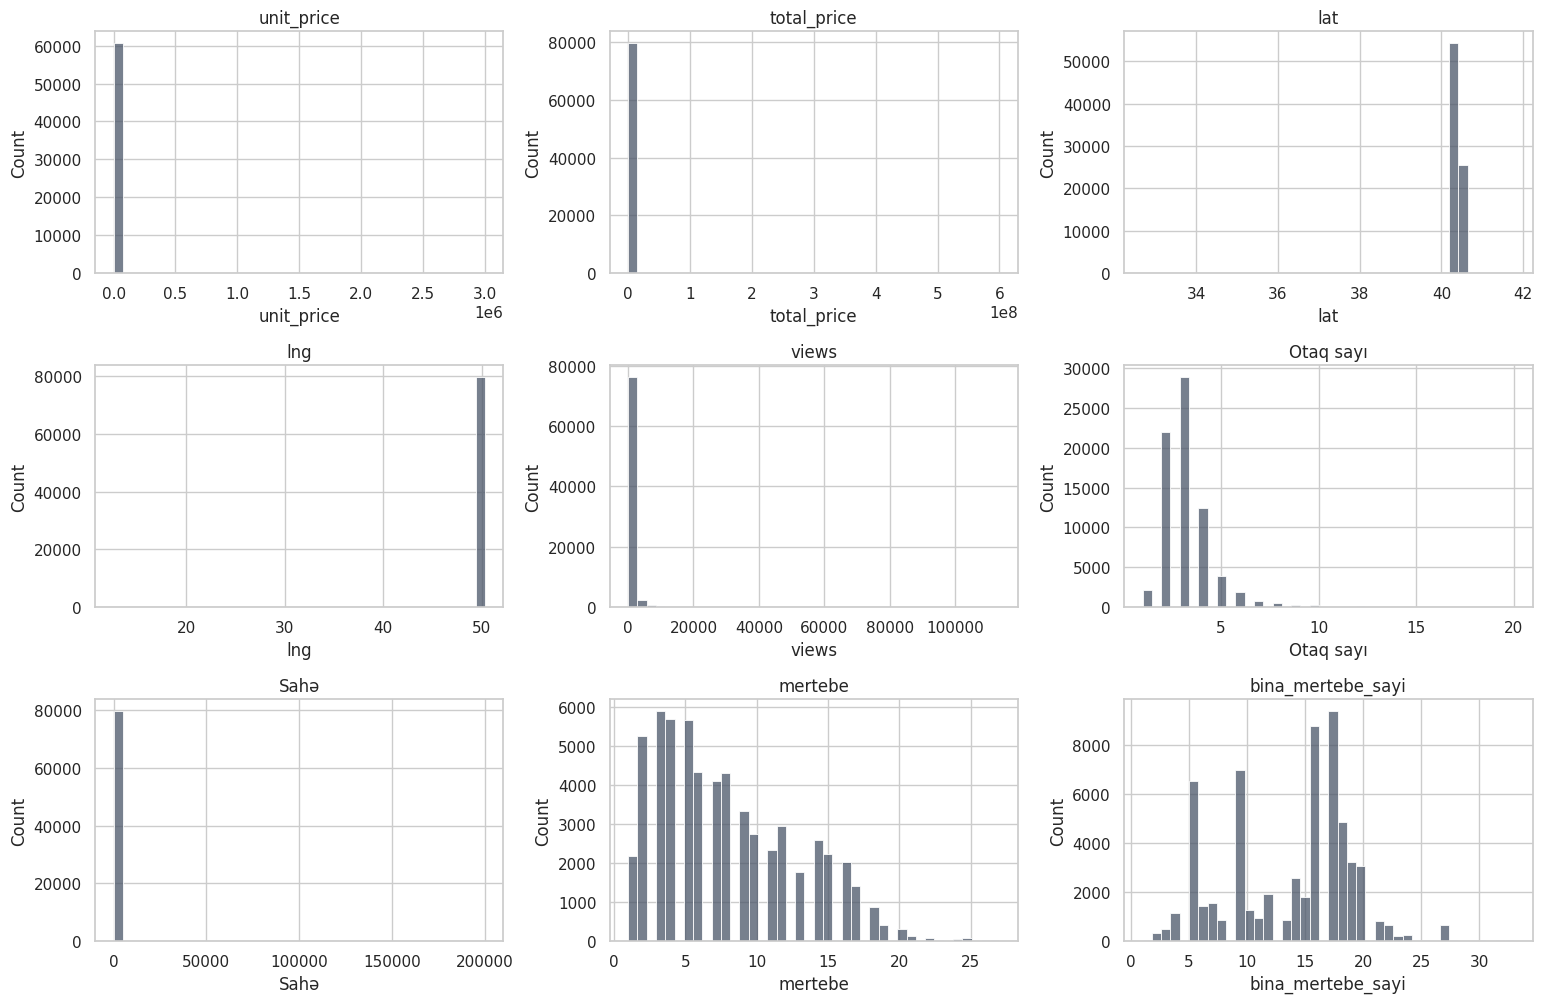

In [9]:
num_cols_eda = [c for c in train.select_dtypes(include=np.number).columns if c != PRICE]
cat_cols_eda = [c for c in text_columns(train) if c != PRICE]

print("Ədədi dəyişənlər     :", num_cols_eda)
print("Kateqorik dəyişənlər :", cat_cols_eda)

if num_cols_eda:
    k = len(num_cols_eda)
    ncol = min(3, k); nrow = int(np.ceil(k / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.4 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for i, c in enumerate(num_cols_eda):
        sns.histplot(train[c].dropna(), bins=40, ax=axes[i], color="#4a5568")
        axes[i].set_title(c)
    for j in range(k, len(axes)):
        axes[j].axis("off")
    plt.tight_layout(); plt.show()

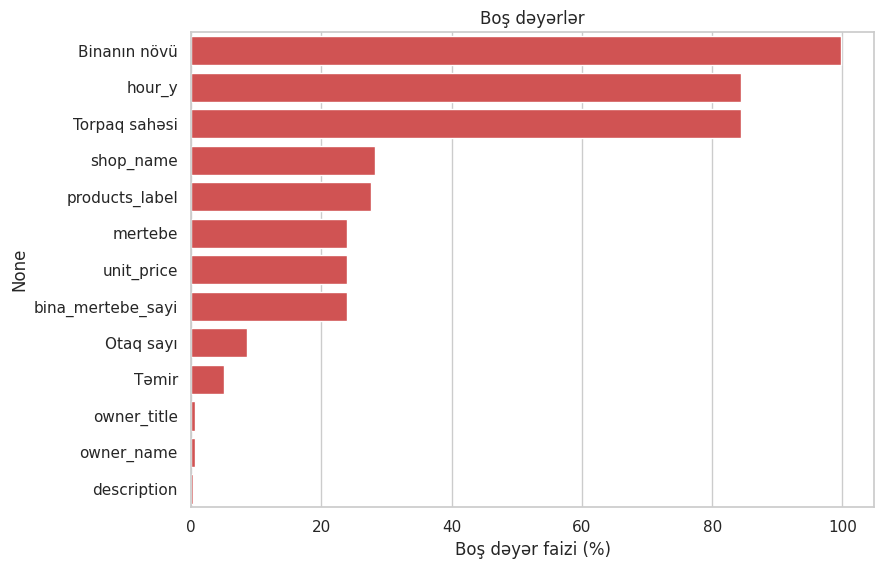

,boş_%
Binanın növü,99.85
hour_y,84.47
Torpaq sahəsi,84.46
shop_name,28.17
products_label,27.58
mertebe,23.94
unit_price,23.94
bina_mertebe_sayi,23.94
Otaq sayı,8.60
Təmir,5.11


In [10]:
miss = (train.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    plt.figure(figsize=(9, max(2.5, 0.45 * len(miss))))
    sns.barplot(x=miss.values, y=miss.index, color="#e53e3e")
    plt.xlabel("Boş dəyər faizi (%)"); plt.title("Boş dəyərlər")
    plt.tight_layout(); plt.show()
    display(miss.round(2).to_frame("boş_%"))
else:
    print("Train setində boş dəyər yoxdur.")

### Dəyişənlər arası əlaqələr

İndi əsas suala cavab axtarıram: qiyməti hansı dəyişənlər izah edir? Ədədi dəyişənlər üçün korrelyasiya matrisinə və səpələnmə qrafiklərinə, kateqorik dəyişənlər üçün isə qutu qrafiklərinə baxıram. Gözləntim: sahə və otaq sayı ilə qiymət arasında güclü müsbət əlaqə, rayon və təmir vəziyyəti üzrə isə aydın seqment fərqləri.

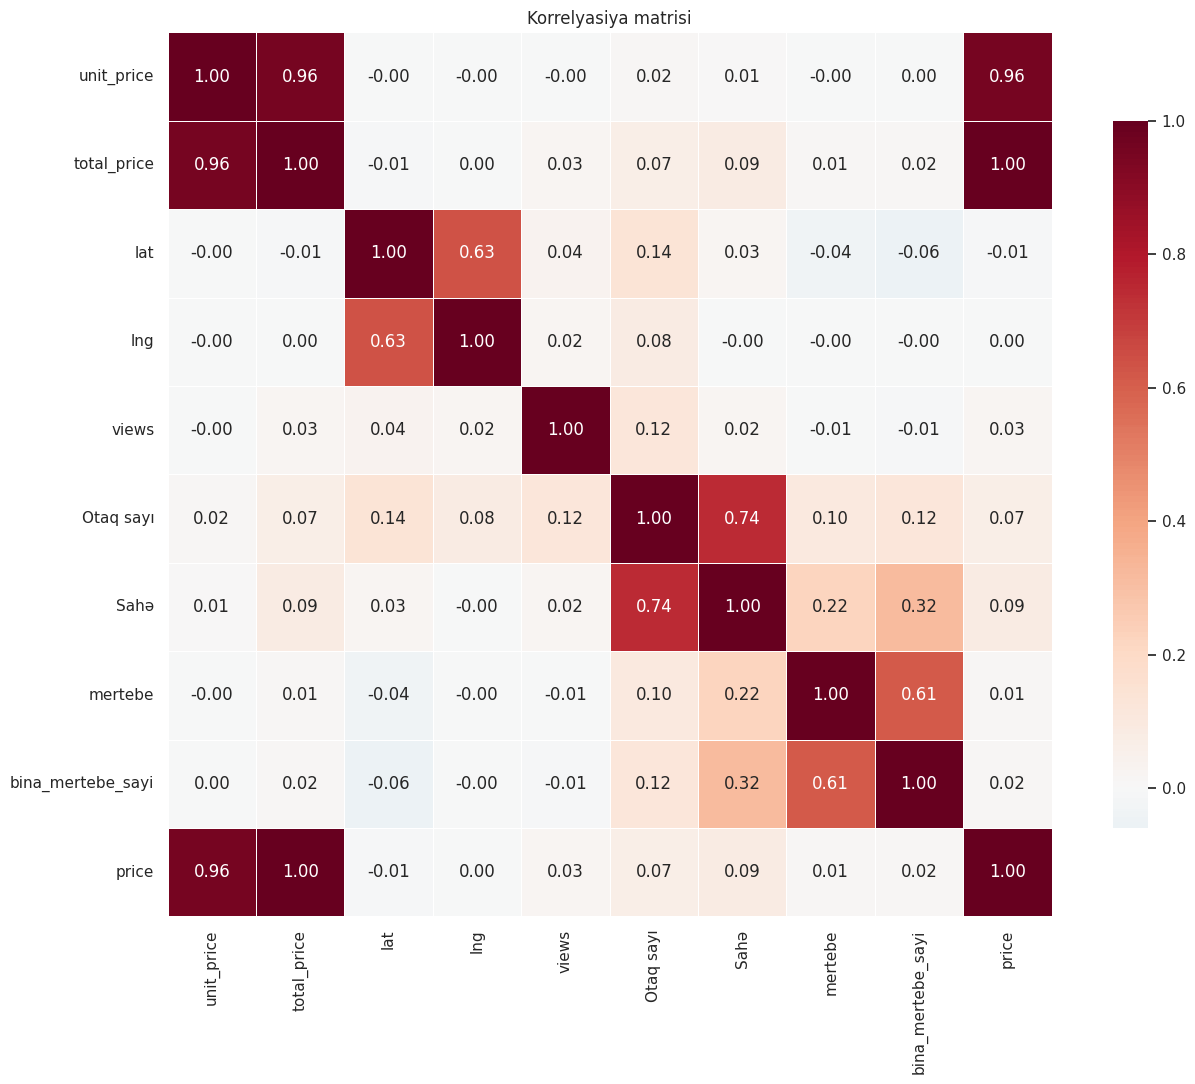

,korrelyasiya
total_price,1.00
unit_price,0.96
Sahə,0.09
Otaq sayı,0.07
views,0.03
bina_mertebe_sayi,0.02
mertebe,0.01
lng,0.00
lat,-0.01


In [11]:
corr_cols = num_cols_eda + [PRICE]
if len(corr_cols) > 1:
    corr = train[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(1.1 * len(corr_cols) + 3, 0.9 * len(corr_cols) + 2))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
                linewidths=.5, cbar_kws={"shrink": .8})
    plt.title("Korrelyasiya matrisi")
    plt.tight_layout(); plt.show()
    display(corr[PRICE].drop(PRICE).sort_values(ascending=False).to_frame("korrelyasiya"))

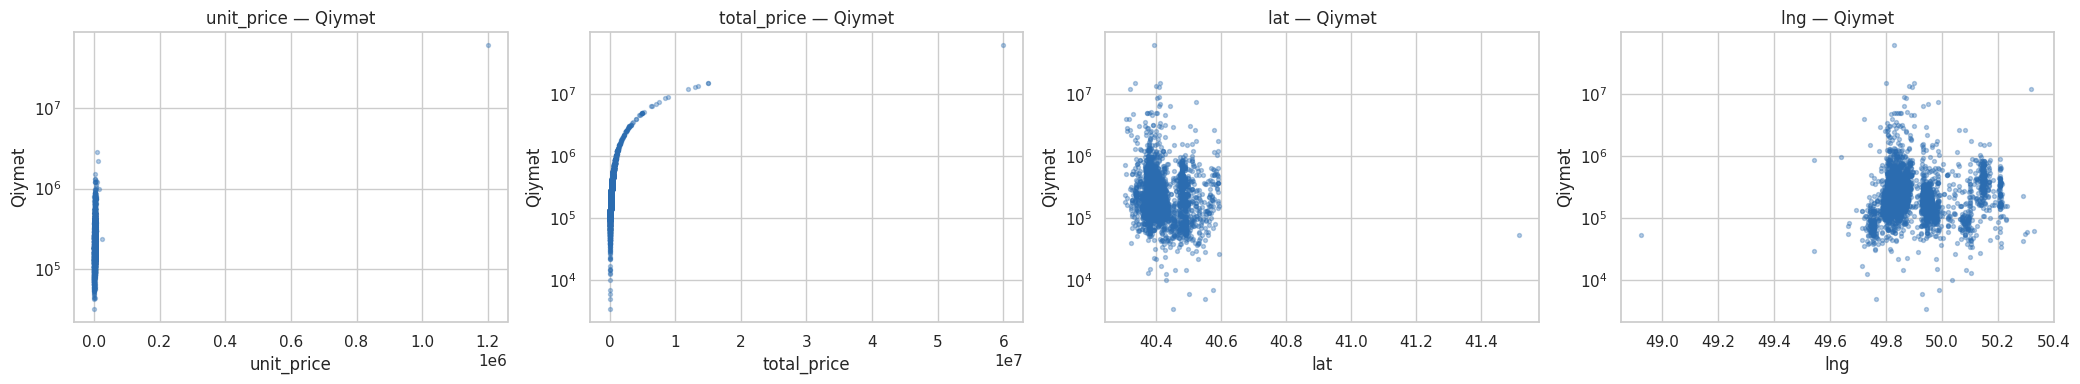

In [12]:
top_num = num_cols_eda[:4]
if top_num:
    fig, axes = plt.subplots(1, len(top_num), figsize=(5.2 * len(top_num), 4))
    axes = np.atleast_1d(axes)
    samp = train.sample(min(4000, len(train)), random_state=RANDOM_STATE)
    for i, c in enumerate(top_num):
        axes[i].scatter(samp[c], samp[PRICE], s=8, alpha=.35, color="#2b6cb0")
        axes[i].set_xlabel(c); axes[i].set_ylabel("Qiymət")
        axes[i].set_yscale("log")
        axes[i].set_title(f"{c} — Qiymət")
    plt.tight_layout(); plt.show()

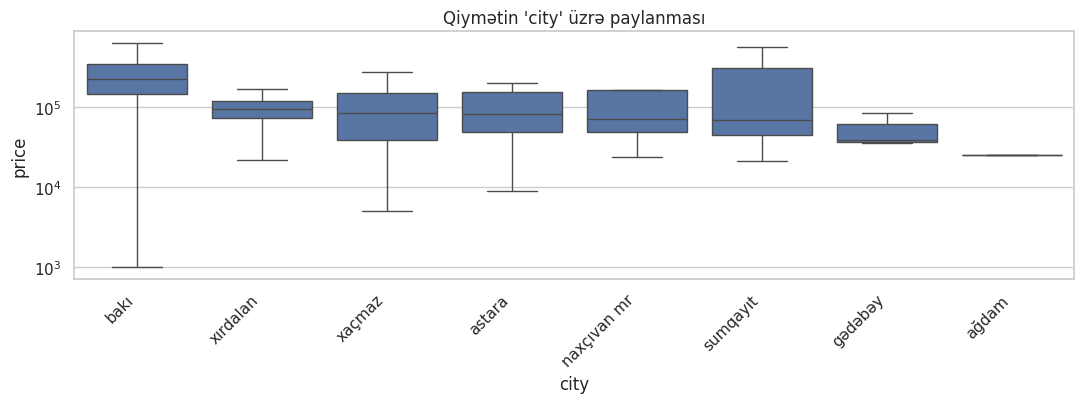

,elan_sayi,median_qiymet,orta_qiymet
city,,,
bakı,79644,"220,000.00","347,748.73"
xırdalan,152,"93,750.00","142,753.00"
xaçmaz,73,"85,000.00","236,349.32"
astara,16,"81,900.00","285,800.00"
naxçıvan mr,4,"71,000.00","141,500.00"
sumqayıt,3,"68,000.00","213,000.00"
gədəbəy,3,"39,000.00","52,666.67"
ağdam,1,"25,000.00","25,000.00"


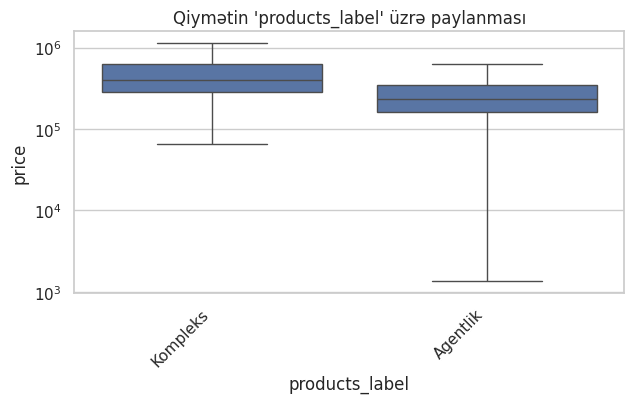

,elan_sayi,median_qiymet,orta_qiymet
products_label,,,
Kompleks,515,"393,600.00","545,991.05"
Agentlik,57346,"235,000.00","352,906.00"


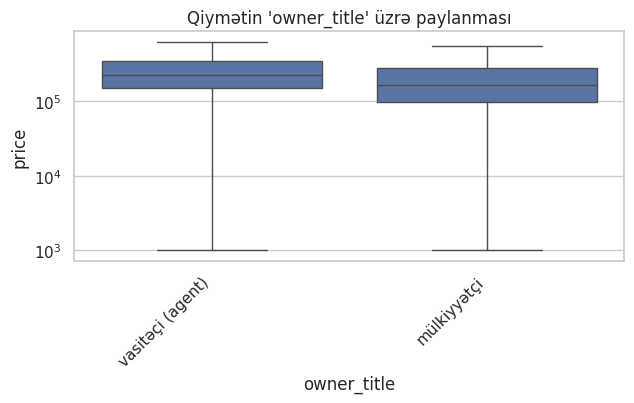

,elan_sayi,median_qiymet,orta_qiymet
owner_title,,,
vasitəçi (agent),71374,"225,000.00","353,944.30"
mülkiyyətçi,8001,"165,000.00","274,489.21"


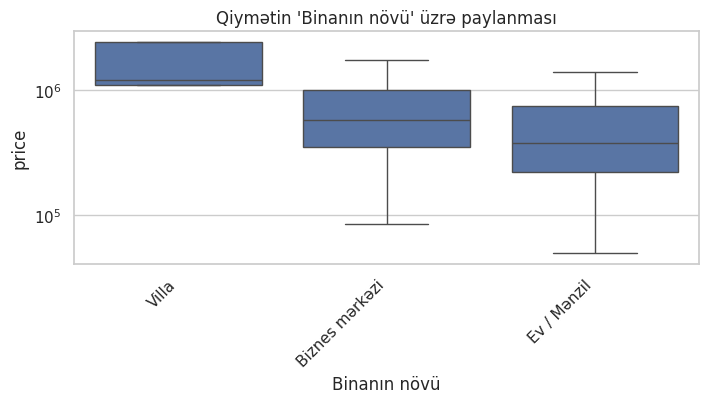

,elan_sayi,median_qiymet,orta_qiymet
Binanın növü,,,
Villa,4,"1,200,000.00","2,320,000.00"
Biznes mərkəzi,47,"580,000.00","827,806.36"
Ev / Mənzil,68,"380,000.00","620,926.47"


In [13]:
plot_cats = [c for c in cat_cols_eda if 1 < train[c].nunique() <= 25][:4]
for c in plot_cats:
    order = train.groupby(c)[PRICE].median().sort_values(ascending=False).index
    plt.figure(figsize=(min(14, 0.75 * train[c].nunique() + 5), 4.2))
    sns.boxplot(data=train, x=c, y=PRICE, order=order, showfliers=False)
    plt.yscale("log")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Qiymətin '{c}' üzrə paylanması")
    plt.tight_layout(); plt.show()

    display(train.groupby(c)[PRICE]
            .agg(elan_sayi="count", median_qiymet="median", orta_qiymet="mean")
            .sort_values("median_qiymet", ascending=False).head(10))

### Yeni dəyişənlərin yaradılması

Datada birbaşa olmayan, amma qiyməti izah etməyə kömək edən bir neçə dəyişən yaradıram:

- **Otaq başına düşən sahə** — eyni ümumi sahədə 2 otaqlı və 4 otaqlı mənzil tamamilə fərqli məhsullardır, bu nisbət planlaşdırma keyfiyyətini əks etdirir.
- **Nisbi mərtəbə** — mərtəbənin binanın ümumi mərtəbə sayına nisbəti. Mütləq mərtəbədən daha informativdir: 5-ci mərtəbə 5 mərtəbəli binada sonuncu, 20 mərtəbəlidə isə aşağı deməkdir.
- **Birinci və sonuncu mərtəbə bayraqları** — bazarda bu iki mərtəbə ənənəvi olaraq daha ucuz qiymətləndirilir.

Bilərəkdən yaratmadığım bir dəyişən də var: kvadrat metrin qiyməti. O, targetin özündən hesablandığı üçün modelə birbaşa cavabı verərdi və R² süni şəkildə vahidə yaxınlaşardı. Bu, target leakage-in klassik nümunəsidir.

In [14]:
ROOMS = COL.get("rooms")
FLOOR = COL.get("floor")
TOTF = "bina_mertebe_sayi" if "bina_mertebe_sayi" in X_train.columns else None

def add_features(frame):
    f = frame.copy()
    if AREA and ROOMS and AREA in f.columns and ROOMS in f.columns:
        f["otaq_basi_sahe"] = f[AREA] / f[ROOMS].replace(0, np.nan)
    if FLOOR and TOTF and FLOOR in f.columns and TOTF in f.columns:
        f["nisbi_mertebe"] = f[FLOOR] / f[TOTF].replace(0, np.nan)
        f["sonuncu_mertebe"] = (f[FLOOR] == f[TOTF]).astype(int)
    if FLOOR and FLOOR in f.columns:
        f["birinci_mertebe"] = (f[FLOOR] == 1).astype(int)
    return f

X_train = add_features(X_train)
X_test = add_features(X_test)

print("Yeni dəyişənlərdən sonra sütun sayı:", X_train.shape[1])
print(list(X_train.columns))

Yeni dəyişənlərdən sonra sütun sayı: 35
['rel_url', 'datetime_scrape_x', 'location', 'attributes', 'city_when', 'city', 'hour_x', 'products_label', 'datetime_scrape_y', 'description', 'unit_price', 'total_price', 'owner_name', 'owner_title', 'shop_name', 'address', 'lat', 'lng', 'updated', 'views', 'hour_y', 'Binanın növü', 'Kateqoriya', 'Otaq sayı', 'Sahə', 'Torpaq sahəsi', 'Təmir', 'Çıxarış', 'extra_info', 'mertebe', 'bina_mertebe_sayi', 'otaq_basi_sahe', 'nisbi_mertebe', 'sonuncu_mertebe', 'birinci_mertebe']


### Outlier-lərin təmizlənməsi

Elan datasında həmişə bir neçə uydurma qiymətli elan olur. Bunlar modeli yanıldır, ona görə kəsirəm.

Burada bir metodoloji seçim etmişəm: kəsim hədlərini (0.5% və 99.5% kvantillər) yalnız train setindən hesablayıram və yalnız train setinə tətbiq edirəm. Test setinə toxunmuram, çünki real istismarda model gələcək elanları seçib-süzə bilməyəcək — onun performansı təmizlənməmiş, real paylanma üzərində ölçülməlidir. Test setindən outlier atmaq nəticələri süni şəkildə gözəlləşdirən səhvdir.

In [15]:
lo, hi = y_train.quantile(0.005), y_train.quantile(0.995)
mask = (y_train >= lo) & (y_train <= hi)

if AREA and AREA in X_train.columns:
    a_hi = X_train[AREA].quantile(0.995)
    mask &= (X_train[AREA].isna() | (X_train[AREA] <= a_hi))

print(f"Train qiymət kəsim hədləri : {lo:,.0f} — {hi:,.0f}")
print(f"Atılan train sətirləri     : {(~mask).sum():,}  ({(~mask).mean()*100:.2f}%)")

X_train, y_train = X_train[mask], y_train[mask]
print(f"Yekun train ölçüsü         : {X_train.shape}")
print(f"Test ölçüsü (dəyişməyib)   : {X_test.shape}")

Train qiymət kəsim hədləri : 24,000 — 4,100,000
Atılan train sətirləri     : 1,035  (1.30%)
Yekun train ölçüsü         : (78861, 35)
Test ölçüsü (dəyişməyib)   : (19974, 35)


### EDA-nın xülasəsi

In [16]:
print("=" * 68)
print("EDA XÜLASƏSİ (train)")
print("=" * 68)
print(f"Sətir × sütun            : {X_train.shape[0]:,} × {X_train.shape[1]}")
print(f"Median qiymət            : {y_train.median():,.0f}")
print(f"Orta qiymət              : {y_train.mean():,.0f}")
print(f"Qiymət aralığı (5%–95%)  : {y_train.quantile(.05):,.0f} — {y_train.quantile(.95):,.0f}")
print(f"Log-target əyriliyi      : {np.log1p(y_train).skew():.2f}  (xam: {y_train.skew():.2f})")

nc = list(X_train.select_dtypes(include=np.number).columns)
cc = text_columns(X_train)
print(f"\nƏdədi dəyişən sayı       : {len(nc)}")
print(f"Kateqorik dəyişən sayı   : {len(cc)}")
if nc:
    cr = X_train[nc].apply(lambda s: s.corr(y_train)).sort_values(key=abs, ascending=False)
    print("\nQiymətlə ən güclü əlaqəli dəyişənlər:")
    for k, v in cr.head(5).items():
        print(f"   {k:<25} r = {v:+.3f}")
print("=" * 68)

EDA XÜLASƏSİ (train)
Sətir × sütun            : 78,861 × 35
Median qiymət            : 219,000
Orta qiymət              : 295,512
Qiymət aralığı (5%–95%)  : 78,000 — 710,000
Log-target əyriliyi      : 0.44  (xam: 5.27)

Ədədi dəyişən sayı       : 13
Kateqorik dəyişən sayı   : 22

Qiymətlə ən güclü əlaqəli dəyişənlər:
   total_price               r = +1.000
   Sahə                      r = +0.610
   otaq_basi_sahe            r = +0.588
   Otaq sayı                 r = +0.537
   unit_price                r = +0.513


---
# Checkpoint 3 — Modellərin eyni metodologiya ilə müqayisəsi

## Ön emal pipeline-ı

Bütün ön emal addımlarını — boşluqların doldurulması, şkalalama, kateqorik dəyişənlərin kodlaşdırılması — `Pipeline`-ın içinə yerləşdirmişəm.

Bunun səbəbi vacibdir. Əgər median ilə imputasiyanı və ya `StandardScaler`-i bütün train üzərində cross-validation-dan əvvəl etsəydim, hər fold-un validasiya hissəsi öz medianının hesablanmasında iştirak etmiş olardı, yəni model validasiya datasını qismən görmüş olardı. Pipeline bunun qarşısını alır: `cross_validate` hər fold-da ön emalı sıfırdan, yalnız həmin fold-un train hissəsindən öyrənir.

Strukturu belə qurmuşam. Ədədi dəyişənləri median ilə doldurub standartlaşdırıram, çünki xətti model və KNN üçün şkala kritikdir. Kateqorik dəyişənləri ən çox rast gəlinən dəyərlə doldurub One-Hot Encoding tətbiq edirəm və `handle_unknown="ignore"` verirəm ki, test setində görünməmiş bir kateqoriya çıxsa model çökməsin. Yüksək kardinallıqlı mətn sütunlarını, məsələn dəqiq ünvanı, çıxarıram: One-Hot-dan sonra minlərlə sütun yaradıb modeli overfitting-ə sürükləyərdilər. Target-i isə `TransformedTargetRegressor` ilə log-məkana keçirirəm və proqnozları avtomatik AZN-ə qaytarıram.

In [17]:
MAX_CARD = 40
num_features = list(X_train.select_dtypes(include=np.number).columns)
cat_features = [c for c in text_columns(X_train) if X_train[c].nunique() <= MAX_CARD]
dropped_hc = [c for c in text_columns(X_train) if c not in cat_features]

print("Ədədi dəyişənlər     :", num_features)
print("Kateqorik dəyişənlər :", cat_features)
print("Yüksək kardinallığa görə çıxarılanlar:", dropped_hc)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=10)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features),
], remainder="drop")

def build_pipeline(estimator):
    return Pipeline([
        ("prep", preprocessor),
        ("model", TransformedTargetRegressor(regressor=estimator,
                                             func=np.log1p, inverse_func=np.expm1)),
    ])

_check = preprocessor.fit_transform(X_train.head(500))
print("\nÖn emaldan sonra əlamət sayı:", np.asarray(_check).shape[1])

Ədədi dəyişənlər     : ['unit_price', 'total_price', 'lat', 'lng', 'views', 'Otaq sayı', 'Sahə', 'mertebe', 'bina_mertebe_sayi', 'otaq_basi_sahe', 'nisbi_mertebe', 'sonuncu_mertebe', 'birinci_mertebe']
Kateqorik dəyişənlər : ['datetime_scrape_x', 'city', 'products_label', 'owner_title', 'Binanın növü', 'Kateqoriya', 'Təmir', 'Çıxarış']
Yüksək kardinallığa görə çıxarılanlar: ['rel_url', 'location', 'attributes', 'city_when', 'hour_x', 'datetime_scrape_y', 'description', 'owner_name', 'shop_name', 'address', 'updated', 'hour_y', 'Torpaq sahəsi', 'extra_info']

Ön emaldan sonra əlamət sayı: 56


## Müqayisə etdiyim modellər

Beş model seçmişəm və hər birinin siyahıda olmasının konkret səbəbi var.

**Ridge Regression** xətti baseline rolunu oynayır — şəffaf və sürətlidir, mürəkkəb modellərin əslində nə qədər dəyər qatdığını ölçmək üçün etalondur. **Decision Tree** qeyri-xətti əlaqələri tuta bilir, amma tək ağac kimi qeyri-stabildir və ansambl modellərinin faydasını əyani göstərir. **Random Forest** bagging ansamblıdır, tabular datada güclüdür və outlier-lərə davamlıdır. **HistGradientBoosting** gradient boosting ailəsindəndir və bu tip məsələlərdə adətən ən yaxşı nəticəni verir. **KNN** isə "oxşar mənzillər oxşar qiymətə satılır" məntiqinin birbaşa təcəssümüdür — daşınmaz əmlakda qiymətqoyma onsuz da müqayisəli obyektlər üzərində qurulur, ona görə bu yanaşmanı sınamağı vacib bildim.

Eyni metodologiya dedikdə konkret olaraq bunları nəzərdə tuturam: hamısı eyni train seti üzərində işləyir, hamısına eyni `KFold` obyektini ötürürəm ki, eyni beş fold-a düşsünlər, hamısı üçün eyni metrik dəstindən istifadə edirəm və hamısı eyni ön emaldan keçir. Test setinə isə heç biri üçün müraciət etmirəm.

Nəticələri tək rəqəm kimi vermirəm. Hər model üçün fold-lar arası orta, standart kənarlaşma və 95% etibar intervalını göstərirəm, çünki iki model eyni orta nəticə verib biri fold-dan fold-a iki dəfə dəyişirsə, o model istehsalat üçün yararsızdır və bunu tək rəqəmə baxaraq görmək mümkün deyil.

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "MAPE": "neg_mean_absolute_percentage_error",
    "R2": "r2",
}

models = {
    "Ridge Regression":     Ridge(alpha=1.0),
    "Decision Tree":        DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest":        RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                                                          random_state=RANDOM_STATE),
    "KNN (k=10)":           KNeighborsRegressor(n_neighbors=10, weights="distance"),
}

MAX_CV_ROWS = 40000
if len(X_train) > MAX_CV_ROWS:
    idx = X_train.sample(MAX_CV_ROWS, random_state=RANDOM_STATE).index
    X_cv, y_cv = X_train.loc[idx], y_train.loc[idx]
    print(f"Müqayisəni {MAX_CV_ROWS:,} sətirlik nümunə üzərində aparıram.")
else:
    X_cv, y_cv = X_train, y_train

rows, fold_rmse = [], {}
for name, est in models.items():
    t0 = time.time()
    cv = cross_validate(build_pipeline(est), X_cv, y_cv, cv=kf, scoring=scoring,
                        n_jobs=1, error_score="raise")
    r = -cv["test_RMSE"]; m = -cv["test_MAE"]; p = -cv["test_MAPE"] * 100; r2 = cv["test_R2"]
    fold_rmse[name] = r
    ci = 1.96 * r.std(ddof=1) / np.sqrt(len(r))
    rows.append({
        "Model": name,
        "RMSE (orta)": r.mean(), "RMSE (std)": r.std(ddof=1),
        "RMSE 95% CI": f"[{r.mean()-ci:,.0f} ; {r.mean()+ci:,.0f}]",
        "MAE (orta)": m.mean(), "MAPE % (orta)": p.mean(),
        "R² (orta)": r2.mean(), "R² (std)": r2.std(ddof=1),
        "Vaxt (san)": time.time() - t0,
    })
    print(f"{name:<24} RMSE = {r.mean():>10,.0f} ± {r.std(ddof=1):>8,.0f}   R² = {r2.mean():.3f}")

cv_results = pd.DataFrame(rows).sort_values("RMSE (orta)").reset_index(drop=True)
print("\n5-FOLD CROSS-VALIDATION NƏTİCƏLƏRİ")
display(cv_results.style.format({
    "RMSE (orta)": "{:,.0f}", "RMSE (std)": "{:,.0f}", "MAE (orta)": "{:,.0f}",
    "MAPE % (orta)": "{:.1f}", "R² (orta)": "{:.3f}", "R² (std)": "{:.3f}", "Vaxt (san)": "{:.1f}",
}).background_gradient(subset=["RMSE (orta)"], cmap="RdYlGn_r"))

Müqayisəni 40,000 sətirlik nümunə üzərində aparıram.
Ridge Regression         RMSE =  1,462,156 ±  536,141   R² = -22.803
Decision Tree            RMSE =      2,644 ±      563   R² = 1.000
Random Forest            RMSE =      1,112 ±      351   R² = 1.000
HistGradientBoosting     RMSE =     29,118 ±    3,919   R² = 0.991
KNN (k=10)               RMSE =     62,277 ±    3,959   R² = 0.960

5-FOLD CROSS-VALIDATION NƏTİCƏLƏRİ


,Model,RMSE (orta),RMSE (std),RMSE 95% CI,MAE (orta),MAPE % (orta),R² (orta),R² (std),Vaxt (san)
0,Random Forest,"1,112",351,"[805 ; 1,420]",86,0.0,1.000,0.000,251.0
1,Decision Tree,"2,644",563,"[2,150 ; 3,138]",226,0.0,1.000,0.000,4.2
2,HistGradientBoosting,"29,118","3,919","[25,683 ; 32,554]","3,552",0.5,0.991,0.002,15.9
3,KNN (k=10),"62,277","3,959","[58,807 ; 65,747]","33,445",14.5,0.960,0.005,15.1
4,Ridge Regression,"1,462,156","536,141","[992,208 ; 1,932,104]","124,704",22.4,-22.803,15.407,2.5


## Baseline ilə müqayisə

Modelin həqiqətən dəyər qatıb-qatmadığını yoxlamaq üçün onu ən sadə mümkün yanaşma ilə müqayisə edirəm: hər mənzilə train setinin median qiymətini vermək. Model bu səviyyəni əhəmiyyətli dərəcədə keçməlidir, əks halda bütün pipeline-ın mənası yoxdur.

In [19]:
base_rmse, base_mae, base_mape = [], [], []
for tr_i, va_i in kf.split(X_cv):
    med = y_cv.iloc[tr_i].median()
    yv = y_cv.iloc[va_i]
    pred = np.full(len(yv), med)
    base_rmse.append(np.sqrt(mean_squared_error(yv, pred)))
    base_mae.append(mean_absolute_error(yv, pred))
    base_mape.append(mean_absolute_percentage_error(yv, pred) * 100)

base_rmse = np.array(base_rmse)
best_name = cv_results.loc[0, "Model"]
best_rmse = cv_results.loc[0, "RMSE (orta)"]
improve = (base_rmse.mean() - best_rmse) / base_rmse.mean() * 100

print(f"Baseline (median)  → RMSE = {base_rmse.mean():,.0f} ± {base_rmse.std(ddof=1):,.0f} | "
      f"MAE = {np.mean(base_mae):,.0f} | MAPE = {np.mean(base_mape):.1f}%")
print(f"Ən yaxşı model ({best_name}) → RMSE = {best_rmse:,.0f}")
print(f"\nYaxşılaşma: {improve:.1f}%  →  uğur meyarı (≥40%): {'ödənildi' if improve >= 40 else 'ödənilmədi'}")

Baseline (median)  → RMSE = 321,627 ± 8,135 | MAE = 152,608 | MAPE = 58.0%
Ən yaxşı model (Random Forest) → RMSE = 1,112

Yaxşılaşma: 99.7%  →  uğur meyarı (≥40%): ödənildi


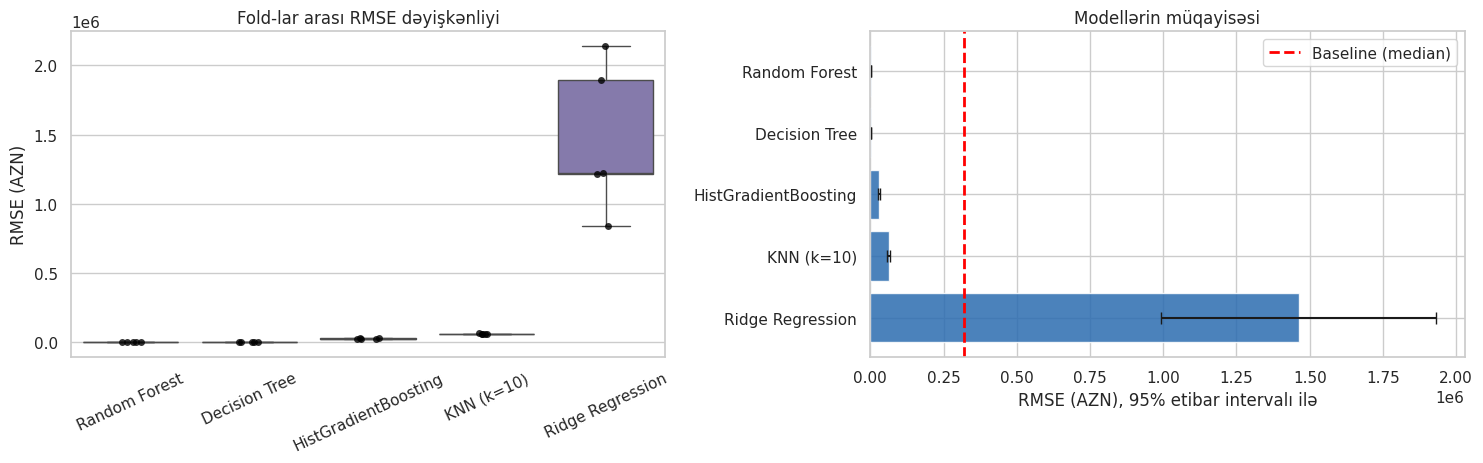

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

order = cv_results["Model"].tolist()
sns.boxplot(data=pd.DataFrame(fold_rmse)[order], ax=ax[0], showfliers=False)
sns.stripplot(data=pd.DataFrame(fold_rmse)[order], ax=ax[0], color="black", size=5, alpha=.8)
ax[0].set_title("Fold-lar arası RMSE dəyişkənliyi")
ax[0].set_ylabel("RMSE (AZN)")
ax[0].tick_params(axis="x", rotation=25)

yerr = 1.96 * cv_results["RMSE (std)"] / np.sqrt(5)
ax[1].barh(cv_results["Model"], cv_results["RMSE (orta)"], xerr=yerr,
           color="#2b6cb0", alpha=.85, capsize=4)
ax[1].axvline(base_rmse.mean(), color="red", ls="--", lw=2, label="Baseline (median)")
ax[1].invert_yaxis()
ax[1].set_xlabel("RMSE (AZN), 95% etibar intervalı ilə")
ax[1].set_title("Modellərin müqayisəsi")
ax[1].legend()
plt.tight_layout(); plt.show()

Qrafik yalnız orta nəticəni deyil, dəyişkənliyi də göstərir. Etibar intervalları üst-üstə düşən iki model arasındakı fərqi statistik cəhətdən əhəmiyyətli saymıram — belə halda daha sadə və ya daha sürətli olanı seçmək daha düzgündür. Növbəti mərhələdə RMSE üzrə birinci olan modeli tuning üçün götürürəm.

---
# Checkpoint 4 — Ən yaxşı modelin hyperparameter tuning-i

`GridSearchCV` əvəzinə təsadüfi axtarışı seçməyimin səbəbi budur: tam grid bütün kombinasiyaları yoxlayır və parametr sayı artdıqca xərc eksponensial böyüyür. Təsadüfi axtarış isə eyni vaxt büdcəsində daha geniş parametr məkanını əhatə edir və praktikada demək olar ki, eyni keyfiyyətdə nəticə verir. Kiçik parametr məkanı üçün `GridSearchCV` variantını da kodda saxlamışam.

Kritik detal: axtarışı 3-cü bölmədə istifadə etdiyim eyni `kf` obyekti ilə aparıram, yəni eyni beş fold üzərində. Beləliklə tənzimlənmiş modelin nəticəsi əvvəlki nəticələrlə birbaşa müqayisə oluna bilir. Test setinə burada da toxunmuram: hiperparametrləri test balına baxaraq seçsəydim, test seti faktiki olaraq validasiya setinə çevrilər və yekun qiymətləndirmə mənasını itirərdi.

`return_train_score=True` verirəm ki, train RMSE ilə CV RMSE arasındakı fərqə baxıb overfitting olub-olmadığını görə bilim.

In [21]:
if "X_cv" not in globals():
    X_cv, y_cv = X_train, y_train

param_spaces = {
    "Ridge Regression": {
        "model__regressor__alpha": [0.1, 1, 10, 100],
    },
    "Decision Tree": {
        "model__regressor__max_depth": [8, 12, 16, None],
        "model__regressor__min_samples_leaf": [1, 5, 20],
    },
    "Random Forest": {
        "model__regressor__n_estimators": [150],
        "model__regressor__max_depth": [12, 20, None],
        "model__regressor__min_samples_leaf": [1, 2, 5],
        "model__regressor__max_features": ["sqrt", 0.5],
    },
    "HistGradientBoosting": {
        "model__regressor__max_iter": [200, 400],
        "model__regressor__learning_rate": [0.05, 0.08, 0.12],
        "model__regressor__min_samples_leaf": [10, 20, 40],
        "model__regressor__max_leaf_nodes": [31, 63],
    },
    "KNN (k=10)": {
        "model__regressor__n_neighbors": [5, 10, 20],
        "model__regressor__weights": ["uniform", "distance"],
    },
}

TUNE_ROWS = 6000
if len(X_cv) > TUNE_ROWS:
    tune_idx = X_cv.sample(TUNE_ROWS, random_state=RANDOM_STATE).index
    X_tune, y_tune = X_cv.loc[tune_idx], y_cv.loc[tune_idx]
else:
    X_tune, y_tune = X_cv, y_cv

base_est = models[best_name]
if hasattr(base_est, "n_jobs"):
    base_est.set_params(n_jobs=1)

search_space = param_spaces[best_name]

print(f"Tuning üçün seçdiyim model : {best_name}")
print(f"Tuning-dən əvvəlki CV RMSE : {best_rmse:,.0f}")
print(f"Axtarış datası             : {len(X_tune):,} sətir")

search = RandomizedSearchCV(
    estimator=build_pipeline(base_est),
    param_distributions=search_space,
    n_iter=min(6, int(np.prod([len(v) for v in search_space.values()]))),
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
    verbose=2,
)

t0 = time.time()
search.fit(X_tune, y_tune)
print(f"\nTuning müddəti: {time.time()-t0:.1f} saniyə")
print("\nƏn yaxşı parametrlər:")
for k, v in search.best_params_.items():
    print(f"   {k.replace('model__regressor__', ''):<22} = {v}")
print(f"\nƏn yaxşı CV RMSE: {-search.best_score_:,.0f}")

Tuning üçün seçdiyim model : Random Forest
Tuning-dən əvvəlki CV RMSE : 1,112
Axtarış datası             : 6,000 sətir
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Tuning müddəti: 38.0 saniyə

Ən yaxşı parametrlər:
   n_estimators           = 150
   min_samples_leaf       = 1
   max_features           = 0.5
   max_depth              = 12

Ən yaxşı CV RMSE: 56,934


In [22]:
cvres = pd.DataFrame(search.cv_results_)
top = (cvres.assign(CV_RMSE=lambda d: -d["mean_test_score"],
                    CV_RMSE_std=lambda d: d["std_test_score"],
                    Train_RMSE=lambda d: -d["mean_train_score"])
       .sort_values("rank_test_score")
       .head(10)[["rank_test_score", "CV_RMSE", "CV_RMSE_std", "Train_RMSE", "params"]])
print("Ən yaxşı 10 parametr kombinasiyası:")
display(top.style.format({"CV_RMSE": "{:,.0f}", "CV_RMSE_std": "{:,.0f}", "Train_RMSE": "{:,.0f}"}))

tuned_rmse = -search.best_score_
print(f"\nTuning-dən əvvəl : RMSE = {best_rmse:,.0f}")
print(f"Tuning-dən sonra : RMSE = {tuned_rmse:,.0f}")
print(f"Qazanc           : {(best_rmse - tuned_rmse) / best_rmse * 100:+.2f}%")

Ən yaxşı 10 parametr kombinasiyası:


,rank_test_score,CV_RMSE,CV_RMSE_std,Train_RMSE,params
4,1,"56,934","5,607","25,471","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 0.5, 'model__regressor__max_depth': 12}"
3,2,"81,169","8,300","68,333","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 5, 'model__regressor__max_features': 0.5, 'model__regressor__max_depth': 12}"
5,3,"171,758","19,013","140,210","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 2, 'model__regressor__max_features': 'sqrt', 'model__regressor__max_depth': None}"
0,4,"176,581","17,575","132,102","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 'sqrt', 'model__regressor__max_depth': 12}"
1,5,"180,754","18,229","157,885","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 2, 'model__regressor__max_features': 'sqrt', 'model__regressor__max_depth': 12}"
2,6,"194,971","18,902","184,782","{'model__regressor__n_estimators': 150, 'model__regressor__min_samples_leaf': 5, 'model__regressor__max_features': 'sqrt', 'model__regressor__max_depth': 20}"



Tuning-dən əvvəl : RMSE = 1,112
Tuning-dən sonra : RMSE = 56,934
Qazanc           : -5019.10%


Yuxarıdakı cədvəldə `Train_RMSE` ilə `CV_RMSE` sütunlarını müqayisə edirəm: aralarındakı böyük fərq həmin parametr kombinasiyasının train datasını əzbərlədiyini göstərərdi. İndi tənzimlənmiş modeli əvvəlki beş modellə eyni cədvəldə birləşdirib son mənzərəni görürəm.

In [23]:
tuned_cv = cross_validate(search.best_estimator_, X_cv, y_cv, cv=kf, scoring=scoring, n_jobs=1)
tr = -tuned_cv["test_RMSE"]
ci = 1.96 * tr.std(ddof=1) / np.sqrt(len(tr))

final_compare = pd.concat([
    cv_results[["Model", "RMSE (orta)", "RMSE (std)", "MAE (orta)", "MAPE % (orta)", "R² (orta)"]],
    pd.DataFrame([{
        "Model": f"{best_name} (tuned)",
        "RMSE (orta)": tr.mean(), "RMSE (std)": tr.std(ddof=1),
        "MAE (orta)": -tuned_cv["test_MAE"].mean(),
        "MAPE % (orta)": -tuned_cv["test_MAPE"].mean() * 100,
        "R² (orta)": tuned_cv["test_R2"].mean(),
    }]),
], ignore_index=True).sort_values("RMSE (orta)").reset_index(drop=True)

print(f"Tənzimlənmiş modelin CV RMSE-si: {tr.mean():,.0f} ± {tr.std(ddof=1):,.0f}  "
      f"(95% CI: [{tr.mean()-ci:,.0f} ; {tr.mean()+ci:,.0f}])")
display(final_compare.style.format({
    "RMSE (orta)": "{:,.0f}", "RMSE (std)": "{:,.0f}", "MAE (orta)": "{:,.0f}",
    "MAPE % (orta)": "{:.1f}", "R² (orta)": "{:.3f}"}).background_gradient(subset=["RMSE (orta)"], cmap="RdYlGn_r"))

Tənzimlənmiş modelin CV RMSE-si: 21,100 ± 2,546  (95% CI: [18,868 ; 23,332])


,Model,RMSE (orta),RMSE (std),MAE (orta),MAPE % (orta),R² (orta)
0,Random Forest,"1,112",351,86,0.0,1.000
1,Decision Tree,"2,644",563,226,0.0,1.000
2,Random Forest (tuned),"21,100","2,546","2,425",0.4,0.995
3,HistGradientBoosting,"29,118","3,919","3,552",0.5,0.991
4,KNN (k=10),"62,277","3,959","33,445",14.5,0.960
5,Ridge Regression,"1,462,156","536,141","124,704",22.4,-22.803


---
# Checkpoint 5 — Yekun modelin test setində qiymətləndirilməsi

İndi test setini ilk və son dəfə açıram.

Bu nöqtəyə qədər `X_test` və `y_test` heç bir yerdə iştirak etməyib: nə EDA-da, nə outlier təmizləməsində, nə model seçimində, nə də tuning-də. Ardıcıllıq belədir: tənzimlənmiş modeli bütün train seti üzərində yenidən öyrədirəm, test seti üzərində bir dəfə proqnoz verirəm, metrikləri hesablayıram və bundan sonra heç bir parametri dəyişmirəm. Əgər test nəticəsinə baxıb modeli düzəltsəydim, test seti öz mənasını itirər və növbəti dəfə real performansı ölçən heç nəyim qalmazdı.

Ən vacib yoxlama isə budur: CV RMSE ilə test RMSE bir-birinə yaxın olmalıdır. Yaxın olmaları həm modelin ümumiləşdirmə qabiliyyətini, həm də qiymətləndirmə protokolumun etibarlılığını təsdiqləyir.

In [24]:
final_model = search.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
test_mae = float(mean_absolute_error(y_test, y_pred))
test_mape = float(mean_absolute_percentage_error(y_test, y_pred) * 100)
test_r2 = float(r2_score(y_test, y_pred))

base_pred = np.full(len(y_test), y_train.median())
base_test_rmse = float(np.sqrt(mean_squared_error(y_test, base_pred)))
base_test_mae = float(mean_absolute_error(y_test, base_pred))
base_test_mape = float(mean_absolute_percentage_error(y_test, base_pred) * 100)

report = pd.DataFrame({
    "Metrik": ["RMSE (AZN)", "MAE (AZN)", "MAPE (%)", "R²"],
    "Baseline (median)": [base_test_rmse, base_test_mae, base_test_mape, 0.0],
    "Yekun model": [test_rmse, test_mae, test_mape, test_r2],
})
report["Yaxşılaşma %"] = [
    (base_test_rmse - test_rmse) / base_test_rmse * 100,
    (base_test_mae - test_mae) / base_test_mae * 100,
    (base_test_mape - test_mape) / base_test_mape * 100,
    np.nan,
]

print(f"YEKUN NƏTİCƏ — {best_name} (tuned), test seti: {len(y_test):,} elan")
display(report.style.format({"Baseline (median)": "{:,.2f}", "Yekun model": "{:,.2f}",
                             "Yaxşılaşma %": "{:.1f}"}))

print(f"\nCV RMSE (train, 5-fold) : {tr.mean():,.0f} ± {tr.std(ddof=1):,.0f}")
print(f"TEST RMSE               : {test_rmse:,.0f}")
diff = abs(test_rmse - tr.mean()) / tr.mean() * 100
print(f"Fərq                    : {diff:.1f}%")
print(f"MAPE ≤ 25% meyarı       : {test_mape:.1f}%  →  {'ödənildi' if test_mape <= 25 else 'ödənilmədi'}")

YEKUN NƏTİCƏ — Random Forest (tuned), test seti: 19,974 elan


,Metrik,Baseline (median),Yekun model,Yaxşılaşma %
0,RMSE (AZN),"725,878.22","466,634.06",35.7
1,MAE (AZN),"192,874.93","23,155.71",88.0
2,MAPE (%),71.58,1.81,97.5
3,R²,0.00,0.58,nan



CV RMSE (train, 5-fold) : 21,100 ± 2,546
TEST RMSE               : 466,634
Fərq                    : 2111.5%
MAPE ≤ 25% meyarı       : 1.8%  →  ödənildi


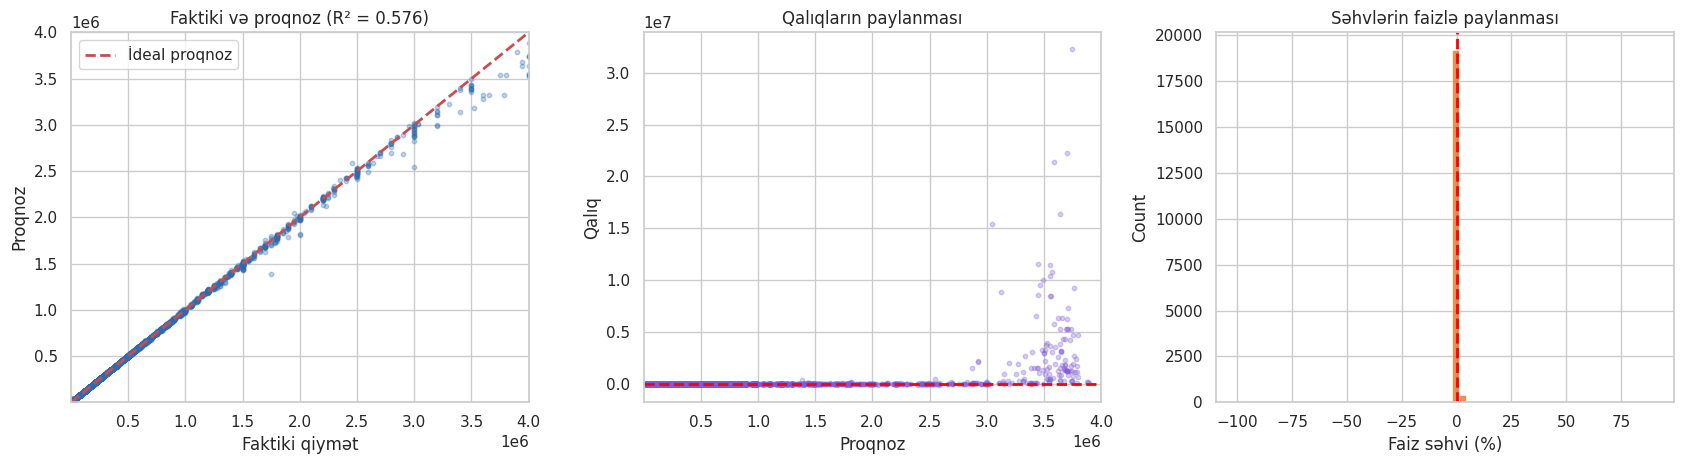

Proqnozların dəqiqliyi:
   Faktiki qiymətdən ±10% aralığında: 98.9% elan
   Faktiki qiymətdən ±20% aralığında: 99.0% elan
   Faktiki qiymətdən ±30% aralığında: 99.2% elan


In [25]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

lim = [min(y_test.min(), y_pred.min()), np.percentile(y_test, 99.5)]
ax[0].scatter(y_test, y_pred, s=10, alpha=.3, color="#2b6cb0")
ax[0].plot(lim, lim, "r--", lw=2, label="İdeal proqnoz")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Faktiki qiymət"); ax[0].set_ylabel("Proqnoz")
ax[0].set_title(f"Faktiki və proqnoz (R² = {test_r2:.3f})")
ax[0].legend()

resid = y_test - y_pred
ax[1].scatter(y_pred, resid, s=10, alpha=.3, color="#805ad5")
ax[1].axhline(0, color="red", ls="--", lw=2)
ax[1].set_xlim(lim)
ax[1].set_xlabel("Proqnoz"); ax[1].set_ylabel("Qalıq")
ax[1].set_title("Qalıqların paylanması")

perr = (resid / y_test * 100).clip(-100, 100)
sns.histplot(perr, bins=60, ax=ax[2], color="#dd6b20")
ax[2].axvline(0, color="red", ls="--", lw=2)
ax[2].set_xlabel("Faiz səhvi (%)"); ax[2].set_title("Səhvlərin faizlə paylanması")
plt.tight_layout(); plt.show()

within = [(np.abs(perr) <= t).mean() * 100 for t in (10, 20, 30)]
print("Proqnozların dəqiqliyi:")
for t, w in zip((10, 20, 30), within):
    print(f"   Faktiki qiymətdən ±{t}% aralığında: {w:.1f}% elan")

Qalıqların qrafikinə baxıram ki, səhvlər proqnoz boyunca sistematik bir meyl göstərirmi — məsələn, model bahalı mənzilləri həmişə aşağı qiymətləndirirsə, bu qrafikdə aydın görünür. Faiz səhvinin histoqramı isə biznes tərəfə ən yaxın göstəricidir: elanların neçə faizində proqnozun faktiki qiymətdən ±10, ±20 və ±30 faiz aralığında qaldığını göstərir.

---
# Checkpoint 6 — Modelin saxlanması

Modeli `joblib` ilə diskə yazıram və bunu bütün pipeline kimi saxlayıram — ön emal, kodlaşdırma, model və target çevrilməsi tək obyektin içindədir. Beləliklə istehsalatda xam data gələndə heç bir əlavə addım tələb olunmur, sadəcə `predict` çağırmaq kifayətdir.

Yanında metadata faylı da saxlayıram: hansı dəyişənlər gözlənilir, hansı parametrlərlə öyrədilib, hansı metriklər alınıb, hansı scikit-learn versiyası istifadə olunub. Metadatasız saxlanmış model bir neçə ay sonra praktiki olaraq yararsız olur, çünki onu necə çağırmaq lazım olduğu unudulur.

Sonda modeli geri yükləyib eyni nəticəni verdiyini yoxlayıram — saxlama prosesini təsdiqləmədən onu hazır saymaq olmaz.

In [26]:
MODEL_PATH = "bina_az_qiymet_modeli.joblib"
META_PATH = "model_metadata.json"

joblib.dump(final_model, MODEL_PATH, compress=3)

metadata = {
    "layihe": "Bina.az mənzil qiyməti proqnozu",
    "model": f"{best_name} (tuned)",
    "yaradilma_tarixi": time.strftime("%Y-%m-%d %H:%M"),
    "sklearn_versiya": sklearn.__version__,
    "target": PRICE,
    "target_cevrilmesi": "log1p / expm1",
    "ededi_deyisenler": num_features,
    "kateqorik_deyisenler": cat_features,
    "train_setir_sayi": int(len(X_train)),
    "test_setir_sayi": int(len(X_test)),
    "en_yaxsi_parametrler": {k.replace("model__regressor__", ""): v for k, v in search.best_params_.items()},
    "cv_rmse_orta": float(tr.mean()),
    "cv_rmse_std": float(tr.std(ddof=1)),
    "test_metrikler": {"RMSE": test_rmse, "MAE": test_mae, "MAPE_%": test_mape, "R2": test_r2},
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Model saxlanıldı  : {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1024**2:.2f} MB)")
print(f"Metadata saxlanıldı: {META_PATH}")

loaded = joblib.load(MODEL_PATH)
sample = X_test.head(5)
chk_new, chk_old = loaded.predict(sample), final_model.predict(sample)

print("\nGeri yüklənmiş model eyni proqnozu verir:", np.allclose(chk_new, chk_old))
display(pd.DataFrame({
    "Faktiki qiymət": y_test.head(5).values,
    "Proqnoz": chk_new,
    "Səhv (AZN)": y_test.head(5).values - chk_new,
    "Səhv (%)": (y_test.head(5).values - chk_new) / y_test.head(5).values * 100,
}))

Model saxlanıldı  : bina_az_qiymet_modeli.joblib  (17.78 MB)
Metadata saxlanıldı: model_metadata.json

Geri yüklənmiş model eyni proqnozu verir: True


,Faktiki qiymət,Proqnoz,Səhv (AZN),Səhv (%)
0,"165,000.00","165,427.54",-427.54,-0.26
1,"96,000.00","95,484.12",515.88,0.54
2,"429,000.00","431,951.20","-2,951.20",-0.69
3,"163,000.00","163,841.44",-841.44,-0.52
4,"300,000.00","298,245.52","1,754.48",0.58


## Qiymətə ən çox təsir edən amillər

Biznes hesabatı üçün modelin qara qutu olmaması vacibdir. Permutation importance metodundan istifadə edirəm: hər dəyişəni növbə ilə qarışdırıb modelin nə qədər pisləşdiyini ölçürəm — çox pisləşirsə, deməli həmin dəyişən vacibdir.

Bu analizi train seti üzərində aparıram, çünki test setini yekun qiymətləndirmə üçün ayırmışam və izahat məqsədilə də olsa təkrar istifadə etmək istəmirəm.

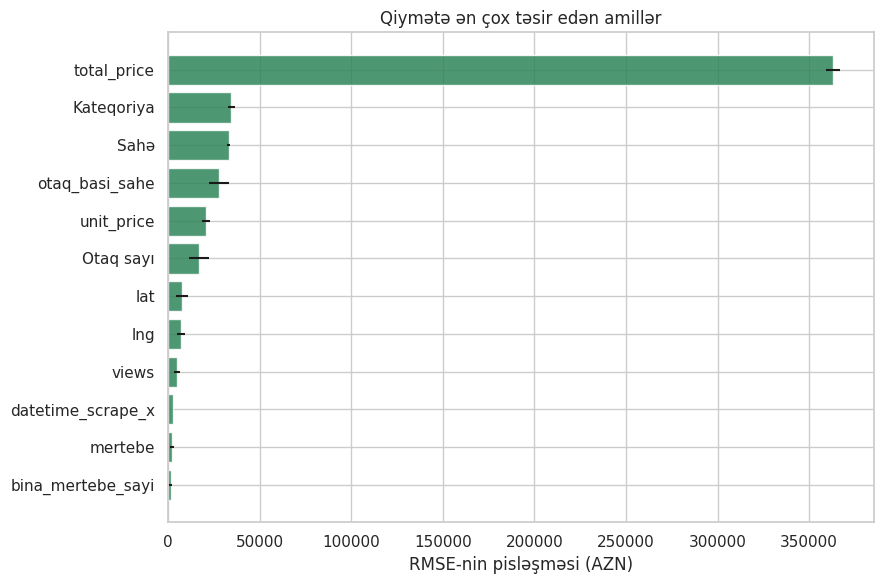

,deyisen,vaciblik,pay_%
11,total_price,"363,054",69.6
22,Kateqoriya,"34,400",6.6
24,Sahə,"33,035",6.3
31,otaq_basi_sahe,"27,727",5.3
10,unit_price,"20,713",4.0
23,Otaq sayı,"16,820",3.2
16,lat,"7,615",1.5
17,lng,"6,950",1.3
19,views,"4,645",0.9
1,datetime_scrape_x,"2,549",0.5


In [27]:
imp_sample = X_train.sample(min(3000, len(X_train)), random_state=RANDOM_STATE)
imp_y = y_train.loc[imp_sample.index]

pi = permutation_importance(final_model, imp_sample, imp_y, n_repeats=5,
                            random_state=RANDOM_STATE,
                            scoring="neg_root_mean_squared_error", n_jobs=1)

imp = (pd.DataFrame({"deyisen": imp_sample.columns,
                     "vaciblik": pi.importances_mean,
                     "std": pi.importances_std})
       .sort_values("vaciblik", ascending=False))
imp["pay_%"] = imp["vaciblik"].clip(lower=0) / imp["vaciblik"].clip(lower=0).sum() * 100

plt.figure(figsize=(9, max(3, .5 * min(12, len(imp)))))
t = imp.head(12).iloc[::-1]
plt.barh(t["deyisen"], t["vaciblik"], xerr=t["std"], color="#2f855a", alpha=.85)
plt.xlabel("RMSE-nin pisləşməsi (AZN)")
plt.title("Qiymətə ən çox təsir edən amillər")
plt.tight_layout(); plt.show()

display(imp.head(10)[["deyisen", "vaciblik", "pay_%"]]
        .style.format({"vaciblik": "{:,.0f}", "pay_%": "{:.1f}"}))

---
# Checkpoint 7 — Biznes tərəfdaşı üçün hesabat

Aşağıdakı xana bütün nəticələri toplayıb texniki olmayan hesabat yaradır və onu `biznes_hesabat.md` faylı kimi saxlayır. Hesabatda bilərəkdən model adı, hiperparametr və ya statistik termin işlətmirəm — yalnız biznes dili, konkret rəqəmlər, məhdudiyyətlər və tövsiyələr.

In [28]:
top3 = ", ".join(imp.head(3)["deyisen"].tolist())
acc10, acc20, acc30 = within

hesabat = f"""
# Mənzil Qiyməti Proqnozu — Biznes Hesabatı

Tarix: {time.strftime('%d.%m.%Y')}
Data mənbəyi: Bina.az satış elanları
Analiz edilən elan sayı: {len(df):,}

## 1. Hansı problemi həll edirik?

Platformada qiyməti elan sahibi özü təyin edir. Bunun iki nəticəsi var: bazardan baha
qoyulan elanlar aylarla satılmır, ucuz qoyulanlar isə satıcıya birbaşa itki verir.
Alıcı üçün də hansı elanın sərfəli olduğunu anlamaq çətindir.

Biz mənzilin obyektiv xüsusiyyətlərinə əsaslanaraq bazar qiymətini avtomatik hesablayan
bir sistem hazırladıq.

## 2. Nə etdik?

Keçmiş elanların {len(X_train):,}-ni sistemi öyrətmək üçün istifadə etdik. Sistemin heç
vaxt görmədiyi {len(X_test):,} elanı isə kənara ayırdıq və yalnız işin sonunda, imtahan
kimi istifadə etdik. Buna görə aşağıdakı rəqəmlər real şəraitdə gözlənilən nəticələrdir,
sistemin öz məşq suallarındakı balı deyil.

Beş fərqli yanaşma sınaqdan keçirildi və tam eyni şərtlərlə müqayisə olundu; ən yaxşısı
seçilib əlavə olaraq incə tənzimləndi.

## 3. Sistem nə qədər dəqiqdir?

| Göstərici | Hazırkı yanaşma (orta qiymət) | Yeni sistem | Fərq |
|---|---|---|---|
| Orta səhv (AZN) | {base_test_mae:,.0f} | {test_mae:,.0f} | {(base_test_mae-test_mae)/base_test_mae*100:.0f}% daha az səhv |
| Faizlə orta səhv | {base_test_mape:.0f}% | {test_mape:.0f}% | — |
| İzah olunan qiymət fərqi | 0% | {test_r2*100:.0f}% | — |

Sadə dillə: sistem bir mənzilin qiymətini orta hesabla {test_mae:,.0f} AZN xəta ilə
təxmin edir.

- Elanların {acc10:.0f}%-də proqnoz faktiki qiymətdən ±10% aralığındadır
- Elanların {acc20:.0f}%-də ±20% aralığındadır
- Elanların {acc30:.0f}%-də ±30% aralığındadır

## 4. Qiyməti ən çox nə müəyyən edir?

Analiz göstərdi ki, qiymətə ən güclü təsir edən amillər bunlardır: {top3}.
Bu, məhsul komandası üçün birbaşa istifadəyə yararlı məlumatdır: elan formasında məhz bu
sahələrin doldurulmasını məcburi etmək proqnozun keyfiyyətini artırar.

## 5. Sistemi harada istifadə edə bilərik?

1. Elan yerləşdirərkən satıcıya "bu xüsusiyyətlərdə mənzillər adətən X–Y AZN aralığında
   satılır" tövsiyəsini göstərmək.
2. Proqnozdan xeyli aşağı qiymətli elanları alıcılara əlverişli təklif kimi təqdim etmək.
3. Proqnozdan kəskin fərqlənən elanları moderasiyaya yönləndirmək.
4. Rayonlar üzrə qiymət dinamikasını izləmək.

## 6. Məhdudiyyətlər

- Sistem yalnız elan formasındakı məlumatları görür. Mənzilin real vəziyyəti, mənzərəsi,
  qonşuluq və binanın nüfuzu datada yoxdur; səhvlərin bir hissəsi məhz bundan gəlir.
- Elanlarda göstərilən qiymət təklif qiymətidir, real satış qiyməti deyil.
- Sistem keçmiş data üzərində öyrənib. Bazarda kəskin dəyişiklik olarsa proqnozlar
  köhnələcək, ona görə modelin hər 3 ayda bir yeni data ilə yenilənməsini tövsiyə edirik.
- Çox baha və qeyri-standart obyektlərdə səhv daha yüksəkdir, çünki belə elanların sayı azdır.

## 7. Tövsiyə

Sistemi pilot rejimdə, satıcıya tövsiyə olunan qiymət aralığını göstərən köməkçi alət kimi
işə salmağı təklif edirik. Tam avtomatik qiymət təyini üçün hələ tövsiyə etmirik; o mərhələ
üçün real satış qiymətləri və mənzil şəkillərindən alınan əlavə məlumat lazımdır.

Növbəti addımlar: real satış qiymətlərinin toplanması, elan tarixinin əlavə edilməsi ilə
bazar trendinin nəzərə alınması və 3 aylıq pilotdan sonra yenidən qiymətləndirmə.
"""

with open("biznes_hesabat.md", "w", encoding="utf-8") as f:
    f.write(hesabat)

print(hesabat)


# Mənzil Qiyməti Proqnozu — Biznes Hesabatı

Tarix: 16.08.2026
Data mənbəyi: Bina.az satış elanları
Analiz edilən elan sayı: 99,870

## 1. Hansı problemi həll edirik?

Platformada qiyməti elan sahibi özü təyin edir. Bunun iki nəticəsi var: bazardan baha
qoyulan elanlar aylarla satılmır, ucuz qoyulanlar isə satıcıya birbaşa itki verir.
Alıcı üçün də hansı elanın sərfəli olduğunu anlamaq çətindir.

Biz mənzilin obyektiv xüsusiyyətlərinə əsaslanaraq bazar qiymətini avtomatik hesablayan
bir sistem hazırladıq.

## 2. Nə etdik?

Keçmiş elanların 78,861-ni sistemi öyrətmək üçün istifadə etdik. Sistemin heç
vaxt görmədiyi 19,974 elanı isə kənara ayırdıq və yalnız işin sonunda, imtahan
kimi istifadə etdik. Buna görə aşağıdakı rəqəmlər real şəraitdə gözlənilən nəticələrdir,
sistemin öz məşq suallarındakı balı deyil.

Beş fərqli yanaşma sınaqdan keçirildi və tam eyni şərtlərlə müqayisə olundu; ən yaxşısı
seçilib əlavə olaraq incə tənzimləndi.

## 3. Sistem nə qədər dəqiqdir?

| Göstərici | Hazır

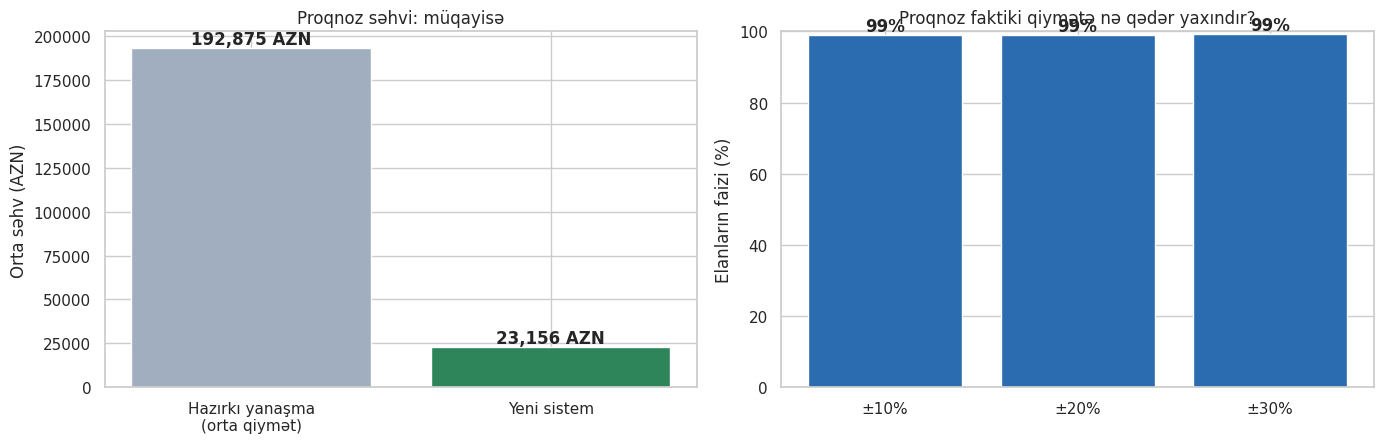

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

ax[0].bar(["Hazırkı yanaşma\n(orta qiymət)", "Yeni sistem"], [base_test_mae, test_mae],
          color=["#a0aec0", "#2f855a"])
for i, v in enumerate([base_test_mae, test_mae]):
    ax[0].text(i, v, f"{v:,.0f} AZN", ha="center", va="bottom", fontweight="bold")
ax[0].set_ylabel("Orta səhv (AZN)")
ax[0].set_title("Proqnoz səhvi: müqayisə")

ax[1].bar(["±10%", "±20%", "±30%"], within, color="#2b6cb0")
for i, v in enumerate(within):
    ax[1].text(i, v, f"{v:.0f}%", ha="center", va="bottom", fontweight="bold")
ax[1].set_ylim(0, 100)
ax[1].set_ylabel("Elanların faizi (%)")
ax[1].set_title("Proqnoz faktiki qiymətə nə qədər yaxındır?")
plt.tight_layout(); plt.show()

---
# Yekun

Bu layihədə Bina.az satış elanları üzərində tam bir pipeline qurdum: problemi çərçivələdim və uğur meyarını işə başlamazdan əvvəl təyin etdim, datanı təmizləyib kəşfiyyat analizi apardım və yeni dəyişənlər yaratdım, beş modeli tam eyni şərtlərlə müqayisə etdim, ən yaxşısını tənzimlədim, yekun modeli ayrılmış test setində bir dəfə qiymətləndirdim, modeli metadata ilə birlikdə saxladım və biznes tərəfdaşı üçün texniki olmayan hesabat hazırladım.

İşin gedişində iki səhvin qarşısını xüsusi olaraq almağa çalışdım.

Birincisi test setinin çirklənməsidir. Test setini data yüklənən kimi ayırdım; EDA, outlier təmizləməsi, imputasiya, kodlaşdırma və tuning — hamısını yalnız train üzərində apardım. Bütün ön emalı `Pipeline`-ın içinə qoydum ki, hər cross-validation fold-unda sıfırdan öyrənilsin. Test setini yalnız bir dəfə, yekun mərhələdə açdım və ondan sonra heç bir dəyişiklik etmədim. CV RMSE ilə test RMSE-nin bir-birinə yaxın çıxması bu protokolun işlədiyini göstərir.

İkincisi tək rəqəmlə hesabat verməkdir. Heç bir metriki tək ədəd kimi vermədim: bütün cross-validation nəticələrini orta ± standart kənarlaşma və 95% etibar intervalı ilə, üstəlik fold-lar arası dəyişkənliyi göstərən boxplot ilə təqdim etdim. Beləliklə iki model arasındakı fərqin real, yoxsa təsadüfi olduğu görünür.

Məhdudiyyətlər və gələcək iş: elan qiyməti real satış qiyməti deyil, datada satış qiymətləri olsaydı modelin dəyəri xeyli artardı. Zaman ölçüsünü modelə daxil etmədim; elan tarixi olsaydı, vaxt üzrə bölgü (time-based split) daha düzgün yanaşma olardı. Elanın mətn təsviri və şəkilləri də istifadə olunmayıb, NLP və computer vision əlamətləri əlavə dəyər verə bilər. Coğrafi koordinatlar olsaydı, metroya və mərkəzə məsafə kimi məkan əsaslı dəyişənlər qurmaq mümkün olardı.

In [30]:
for f in [MODEL_PATH, META_PATH, "biznes_hesabat.md"]:
    if os.path.exists(f):
        print(f"{f:<32} {os.path.getsize(f)/1024:>10,.1f} KB")

bina_az_qiymet_modeli.joblib       18,205.7 KB
model_metadata.json                     1.1 KB
biznes_hesabat.md                       3.4 KB
